**Student Name**: Kaushik V

**Student Roll No**: 21f1001083

**DEADLINE: 30th July, 2023**

# Programming Assignment-2


Make a copy of the colab. Rename the colab as follows:

```
PA-2_<roll-number>.ipynb
```

We will be running your colab. It should produce the graphs/charts as explaind in the problem statements. Add comments wherever necessary. At the end of each problem configuration, enter your observations in the text cell. This should include your analysis of the learning curves obtaind.

### Libraries

Stick to `NumPy` and a library such as `matplotlib`, `seaborn` or `plotly` for rendering plots.

In [ ]:
# import necessary libraries here
import numpy as np
import matplotlib.pyplot as plt

## Environment description

This exercise aims to familiarize you with two popular Temporal Difference Learning algorithms: **SARSA** and **Q-Learning**. You will solve several variants of the Grid World problem (a sample world is shown below in Figure 1).

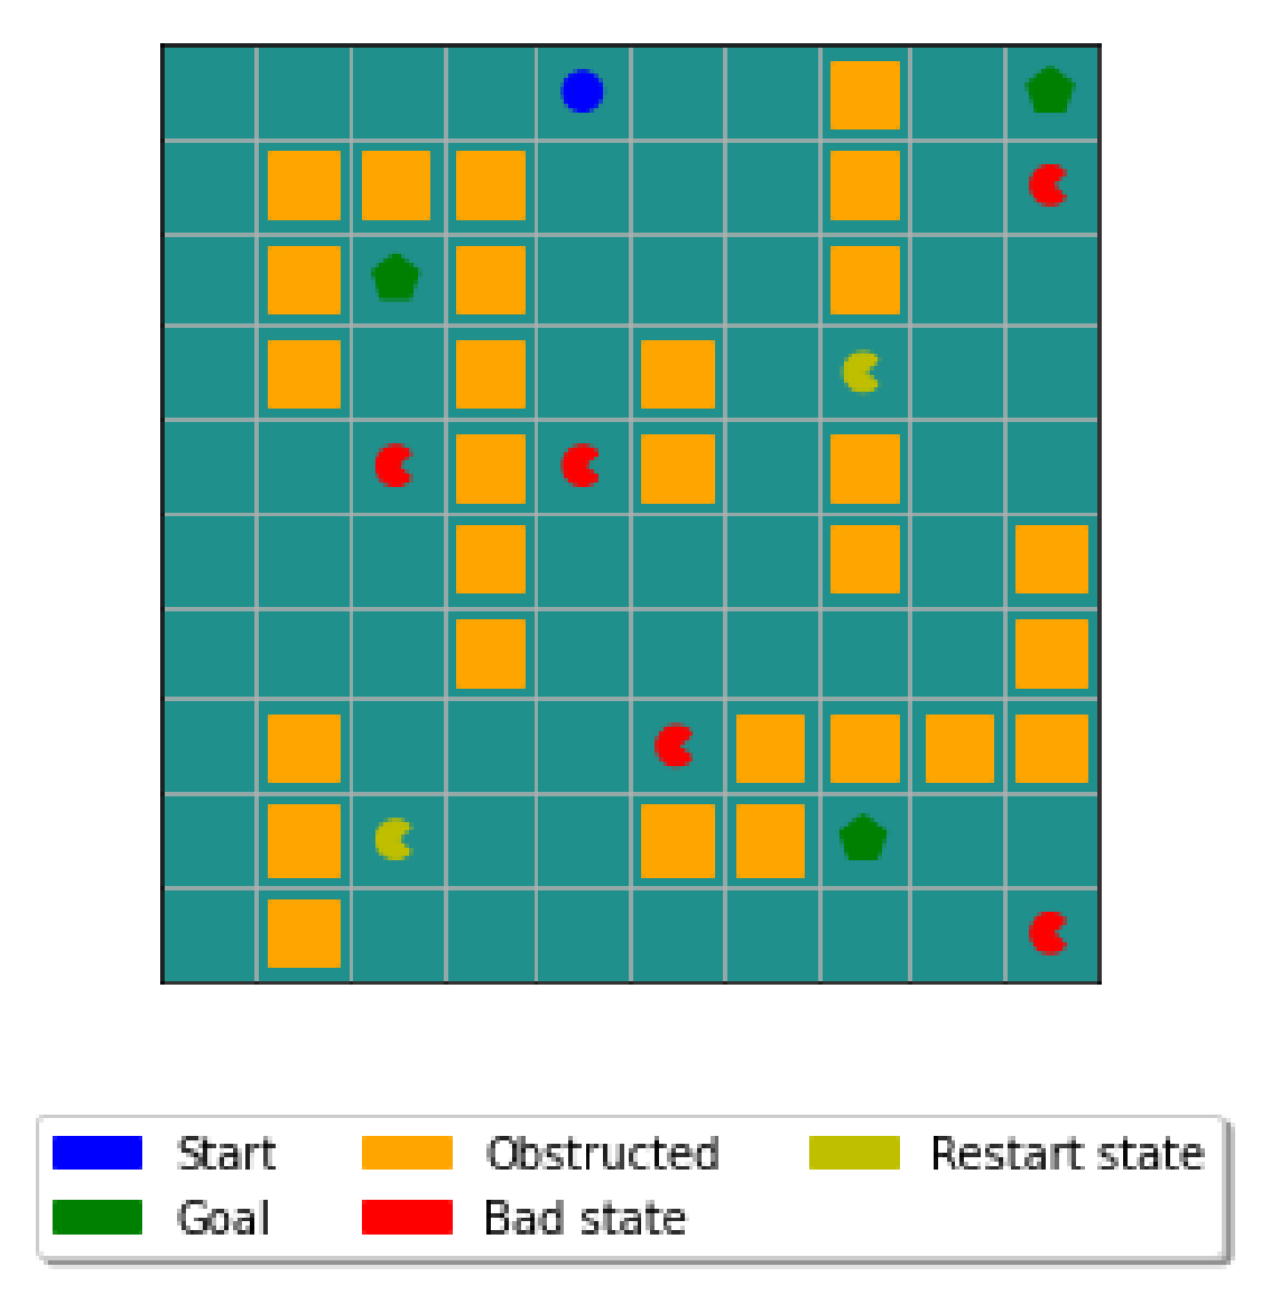

***Figure 1***

This is a grid world with 4 deterministic actions ('up', 'down', 'left', 'right'). The agent transitions to the next state determined by the direction of the action chosen with a probability of $p \in [0, 1]$. We also define a parameter called $b \in [0, 1]$ (Set $b=0.5$ for this assignment). Consider the direction of the action chosen as the agent's “North”. For example, if the action is 'left', it is the agent's North, and the agent's East would be the direction of the action 'up'. Figure 2 provides an illustration of the same. The agent transitions to the state West of the chosen action with probability $(1-p)\times b$, and to the East of the chosen action with probability $(1-p) \times (1-b)$.

 The environment may also have a wind blowing that can push the agent one **additional** cell to the right **after transitioning to the new state** with a probability of 0.4. An episode is terminated either when a goal is reached or when the timesteps exceed 100. Transitions that take you off the grid will not result in any change in state.

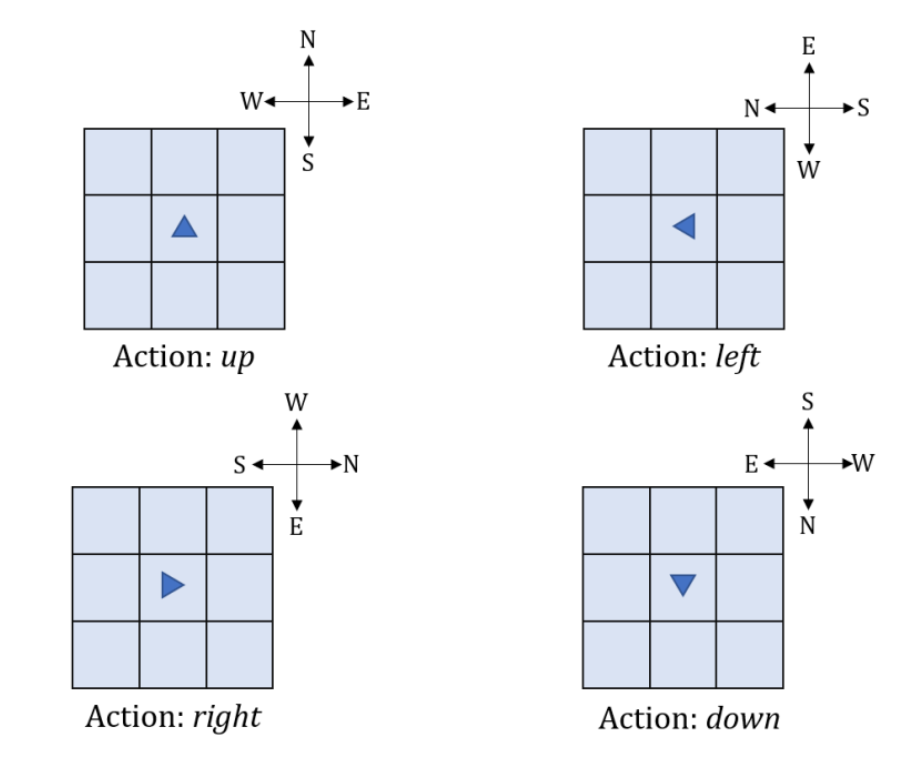

***Figure 2***

The dimensions of the grid are $10 \times 10$. The following types of states exist:

- ***Start state***: The agent starts from this state.
- ***Goal state***: The goal is to reach one of these states. There are 3 goal states in total.

- ***Obstructed state***: These are walls that prevent entry to the respective cells. Transition to these states will not result in any change.

- ***Bad state***: Entry into these states will incur a higher penalty than a normal state.
- ***Restart state***: Entry into these states will incur a very high penalty and will cause agent to teleport to the start state without the episode ending. Once the restart state is reached, no matter what action is chosen, it goes to the start state at the next step.
- ***Normal state***: None of the above. Entry into these states will incur a small penalty.


***Rewards***: -1 for normal states, -100 for restart states, -6 for bad states, +10 for goal states.

## Environment code

The code for the environment can be found below:

In [ ]:
from math import floor
import plotly
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

#Converts state number to row_column format
def row_col_to_seq(row_col, num_cols):
    return row_col[:,0] * num_cols + row_col[:,1]

#Converts row_column format to state number
def seq_to_col_row(seq, num_cols):
    r = floor(seq / num_cols)
    c = seq - r * num_cols
    return np.array([[r, c]])

class GridWorld:
    """
    Creates a gridworld object to pass to an RL algorithm.
    Parameters
    ----------
    num_rows : int
        The number of rows in the gridworld.
    num_cols : int
        The number of cols in the gridworld.
    start_state : numpy array of shape (1, 2), np.array([[row, col]])
        The start state of the gridworld (can only be one start state)
    goal_states : numpy arrany of shape (n, 2)
        The goal states for the gridworld where n is the number of goal
        states.
    """
    def __init__(self, num_rows, num_cols, start_state, goal_states, wind = False):
        self.num_rows = num_rows
        self.num_cols = num_cols
        self.start_state = start_state
        self.goal_states = goal_states
        self.obs_states = None
        self.bad_states = None
        self.num_bad_states = 0
        self.p_good_trans = None
        self.bias = None
        self.r_step = None
        self.r_goal = None
        self.r_dead = None
        self.gamma = 1
        self.wind = wind

    # mark obstructed cells
    def add_obstructions(self, obstructed_states=None, bad_states=None, restart_states=None):

        self.obs_states = obstructed_states
        self.bad_states = bad_states
        if bad_states is not None:
            self.num_bad_states = bad_states.shape[0]
        else:
            self.num_bad_states = 0
        self.restart_states = restart_states
        if restart_states is not None:
            self.num_restart_states = restart_states.shape[0]
        else:
            self.num_restart_states = 0

    def add_transition_probability(self, p_good_transition, bias):

        self.p_good_trans = p_good_transition
        self.bias = bias

    def add_rewards(self, step_reward, goal_reward, bad_state_reward=None, restart_state_reward = None):

        self.r_step = step_reward
        self.r_goal = goal_reward
        self.r_bad = bad_state_reward
        self.r_restart = restart_state_reward


    def create_gridworld(self):

        self.num_actions = 4
        self.num_states = self.num_cols * self.num_rows# +1
        self.start_state_seq = row_col_to_seq(self.start_state, self.num_cols)
        self.goal_states_seq = row_col_to_seq(self.goal_states, self.num_cols)

        # rewards structure
        self.R = self.r_step * np.ones((self.num_states, 1))
        #self.R[self.num_states-1] = 0
        self.R[self.goal_states_seq] = self.r_goal

        for i in range(self.num_bad_states):
            if self.r_bad is None:
                raise Exception("Bad state specified but no reward is given")
            bad_state = row_col_to_seq(self.bad_states[i,:].reshape(1,-1), self.num_cols)
            #print("bad states", bad_state)
            self.R[bad_state, :] = self.r_bad
        for i in range(self.num_restart_states):
            if self.r_restart is None:
                raise Exception("Restart state specified but no reward is given")
            restart_state = row_col_to_seq(self.restart_states[i,:].reshape(1,-1), self.num_cols)
            #print("restart_state", restart_state)
            self.R[restart_state, :] = self.r_restart

        # probability model
        if self.p_good_trans == None:
            raise Exception("Must assign probability and bias terms via the add_transition_probability method.")

        self.P = np.zeros((self.num_states,self.num_states,self.num_actions))
        for action in range(self.num_actions):
            for state in range(self.num_states):

                # check if the state is the goal state or an obstructed state - transition to end
                row_col = seq_to_col_row(state, self.num_cols)
                if self.obs_states is not None:
                    end_states = np.vstack((self.obs_states, self.goal_states))
                else:
                    end_states = self.goal_states

                if any(np.sum(np.abs(end_states-row_col), 1) == 0):
                    self.P[state, state, action] = 1

                # else consider stochastic effects of action
                else:
                    for dir in range(-1,2,1):

                        direction = self._get_direction(action, dir)
                        next_state = self._get_state(state, direction)
                        if dir == 0:
                            prob = self.p_good_trans
                        elif dir == -1:
                            prob = (1 - self.p_good_trans)*(self.bias)
                        elif dir == 1:
                            prob = (1 - self.p_good_trans)*(1-self.bias)

                        self.P[state, next_state, action] += prob

                # make restart states transition back to the start state with
                # probability 1
                if self.restart_states is not None:
                    if any(np.sum(np.abs(self.restart_states-row_col),1)==0):
                        next_state = row_col_to_seq(self.start_state, self.num_cols)
                        self.P[state,:,:] = 0
                        self.P[state,next_state,:] = 1

        return self

    def _get_direction(self, action, direction):

        left = [2,3,1,0]
        right = [3,2,0,1]
        if direction == 0:
            new_direction = action
        elif direction == -1:
            new_direction = left[action]
        elif direction == 1:
            new_direction = right[action]
        else:
            raise Exception("getDir received an unspecified case")
        return new_direction

    def _get_state(self, state, direction):

        row_change = [-1,1,0,0]
        col_change = [0,0,-1,1]
        row_col = seq_to_col_row(state, self.num_cols)
        row_col[0,0] += row_change[direction]
        row_col[0,1] += col_change[direction]

        # check for invalid states
        if self.obs_states is not None:
            if (np.any(row_col < 0) or
                np.any(row_col[:,0] > self.num_rows-1) or
                np.any(row_col[:,1] > self.num_cols-1) or
                np.any(np.sum(abs(self.obs_states - row_col), 1)==0)):
                next_state = state
            else:
                next_state = row_col_to_seq(row_col, self.num_cols)[0]
        else:
            if (np.any(row_col < 0) or
                np.any(row_col[:,0] > self.num_rows-1) or
                np.any(row_col[:,1] > self.num_cols-1)):
                next_state = state
            else:
                next_state = row_col_to_seq(row_col, self.num_cols)[0]

        return next_state

    def reset(self):
      return int(self.start_state_seq)

    def step(self, state, action):
        p, r = 0, np.random.random()
        for next_state in range(self.num_states):

            p += self.P[state, next_state, action]

            if r <= p:
                break

        if(self.wind and np.random.random() < 0.4):

          arr = self.P[next_state, :, 3]
          next_next = np.where(arr == np.amax(arr))
          next_next = next_next[0][0]
          return next_next, self.R[next_next]
        else:
          return next_state, self.R[next_state]

    def visualize_gridworld(self):

        # create a 2D grid with empty cells
        grid_world_2D_array = np.ones((self.num_rows, self.num_cols))*ord("E")

        grid_world_2D_array[self.goal_states[:,0],self.goal_states[:,1]]= ord("G")
        grid_world_2D_array[self.obs_states[:,0],self.obs_states[:,1]]= ord("O")
        grid_world_2D_array[self.start_state[:,0],self.start_state[:,1]]= ord("S")
        grid_world_2D_array[self.bad_states[:,0],self.bad_states[:,1]]= ord("B")
        grid_world_2D_array[self.restart_states[:,0],self.restart_states[:,1]]= ord("R")

        grid_world_2D_array_colours = np.ones((self.num_rows, self.num_cols, 3))

        grid_world_2D_array_colours[grid_world_2D_array== ord("G")] =[0,1,0]
        grid_world_2D_array_colours[grid_world_2D_array== ord("O")] =[1,0.65,0]
        grid_world_2D_array_colours[grid_world_2D_array== ord("S")] =[0,0,1]
        grid_world_2D_array_colours[grid_world_2D_array== ord("B")] =[1,0,0]
        grid_world_2D_array_colours[grid_world_2D_array== ord("R")] =[1,1,0]

        fig = px.imshow(grid_world_2D_array_colours)

        state_label = np.empty_like(grid_world_2D_array,
                                    dtype ="<U10")

        state_label[grid_world_2D_array == ord("E")] ="Empty"
        state_label[grid_world_2D_array == ord("G")] ="Goal"
        state_label[grid_world_2D_array == ord("B")] ="Bad"
        state_label[grid_world_2D_array == ord("S")] ="Start"
        state_label[grid_world_2D_array == ord("R")] ="Restart"
        state_label[grid_world_2D_array == ord("O")] ="Obstacle"

        fig.update(data=[{'customdata': state_label,
                          'hovertemplate': 'x: %{x}<br>y: %{y}<br>State: %{customdata}'}])
        # add vertical and horizontal lines
        [fig.add_vline(x=i, line_width=2, line_dash="solid", line_color="Grey") for i in np.arange(-0.5,10)]
        [fig.add_hline(y=i, line_width=2, line_dash="solid", line_color="Grey") for i in np.arange(-0.5,10)]

        # ensure each row and column is numbered/labeled
        fig.update_layout(
            title ="Grid World Vizualization <br>Hover over to a cell for information",
            xaxis = dict(
                tickmode='linear',
                side='top',
                dtick=1),
            yaxis = dict(
                tickmode='linear',
                dtick=1)
        )
        fig.show()


## Environment instantiation

In [ ]:
# specify world parameters

# size of the grid
num_cols = 10
num_rows = 10

# coordinates of the cells representing obstruction
obstructions = np.array([[0,7],[1,1],[1,2],[1,3],[1,7],[2,1],[2,3],
                         [2,7],[3,1],[3,3],[3,5],[4,3],[4,5],[4,7],
                         [5,3],[5,7],[5,9],[6,3],[6,9],[7,1],[7,6],
                         [7,7],[7,8],[7,9],[8,1],[8,5],[8,6],[9,1]])

# lsit of bad states
bad_states = np.array([[1,9],[4,2],[4,4],[7,5],[9,9]])

# list of restart states
restart_states = np.array([[3,7],[8,2]])

# starting position
start_state = np.array([[0,4]])

# list of goal states i.e. terminal states
goal_states = np.array([[0,9],[2,2],[8,7]])

# create the environment's model
gw = GridWorld(num_rows=num_rows,
               num_cols=num_cols,
               start_state=start_state,
               goal_states=goal_states,
               wind = False)

gw.add_obstructions(obstructed_states=obstructions,
                    bad_states=bad_states,
                    restart_states=restart_states)

gw.add_rewards(step_reward=-1,
               goal_reward=10,
               bad_state_reward=-6,
               restart_state_reward=-100)
gw.add_transition_probability(p_good_transition=0.7,
                              bias=0.5)
env = gw.create_gridworld()

## Visualize the grid world

In [ ]:
# visualize the grid world configuration
env.visualize_gridworld()

## List environment variables

In [ ]:
print("Number of actions", env.num_actions) #0 -> UP, 1-> DOWN, 2 -> LEFT, 3-> RIGHT
print("Number of states", env.num_states)
print("start state", env.start_state_seq)
print("goal state(s)", env.goal_states_seq)

Number of actions 4
Number of states 100
start state [4]
goal state(s) [ 9 22 87]


The $env.step()$ function takes as arguments the current state and action, and returns the reward and next state. The appropriate termination conditions have to be specified by the student in the code. $env.reset()$ resets the environment.

## Tasks
- Implement SARSA and Q-Learning.
- ~~For each algorithm, run experiments with wind=False and wind=True; two different start states: (0, 4), (3, 6); two values of $p$ (1.0, 0.7); and two types of exploration strategies ($\epsilon$-greedy and softmax), making it ***16 different configurations*** in total.~~
- For SARSA, there are a total of $8$ configurations:
  - set $p = 1$
  - wind could take one of two values, `True` or `False`
  - start state could take one of two values: `(0, 4)` or `(3, 6)`
  - exploration strategy could take one of two values: $\epsilon$-greedy or softmax
- For Q-learning, there are a total of $8$ configurations:
  - $p = 1$ or $p = 0.7$
  - set `wind = False`
  - start state could take one of two values: `(0, 4)` or `(3, 6)`
  - exploration strategy could take one of two values: $\epsilon$-greedy or softmax

- There are a total of $16$ configurations.
- For each of the $16$ configurations, determine the best set of hyperparameters (i.e. $ϵ$ in $ϵ$-greedy exploration, temperature $\beta$ in softmax exploration, learning rate $\alpha$, and discount factor $\gamma$) which maximize reward per episode over atleast 100 runs. Plot the following:
  1. Reward curves and the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).
  2. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.
  3. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.
- Try following set of values for each of the hyperparameters, for each of the configurations:

  a. learning rate ($α$) = [0.001, 0.01, 0.1, 1.0]

  b. discount factor ($γ$) = [0.7, 0.8, 0.9, 1.0]

  c. epsilon in $ϵ$-greedy = [0.001, 0.01, 0.05, 0.1] or
  
  Temperature in soft max ($τ$) = [0.01, 0.1, 1, 2]

For each of the algorithm, provide a written description of the policy learnt, explaining
the behavior of the agent, and your choice of hyperparameters. This description should
also provide information about how the behavior changes with and without the wind, for
different levels of stochasticity and for different start states.

The report can be organized in following manner:

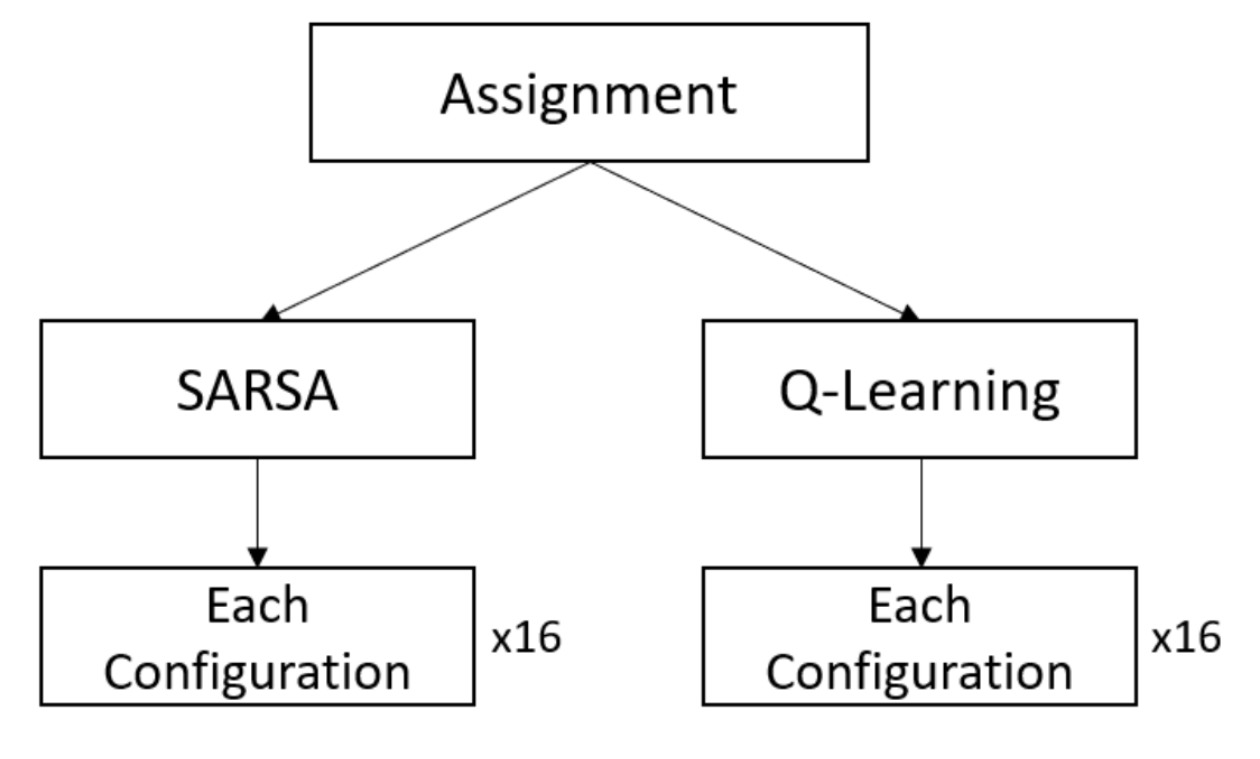

## Configurations [64 Marks]

There are total (~~32~~)16 configurations (~~16~~)8 each for SARSA and Q-Learning), each of which carry (~~2~~)4 marks.

Use below template for each of the configurations.

Hint: For reproducible results set random state appropriately.

Train the agent

## Base Code for all Configurations sets

In [ ]:
#GridWorld Set up
class gwSetUp:
  def __init__(self, wind, p, start_state):
    self.wind = wind
    self.p = p
    self.start_state = start_state
    # specify world parameters

    # size of the grid
    num_cols = 10
    num_rows = 10

    # coordinates of the cells representing obstruction
    obstructions = np.array([[0,7],[1,1],[1,2],[1,3],[1,7],[2,1],[2,3],
                            [2,7],[3,1],[3,3],[3,5],[4,3],[4,5],[4,7],
                            [5,3],[5,7],[5,9],[6,3],[6,9],[7,1],[7,6],
                            [7,7],[7,8],[7,9],[8,1],[8,5],[8,6],[9,1]])

    # lsit of bad states
    bad_states = np.array([[1,9],[4,2],[4,4],[7,5],[9,9]])

    # list of restart states
    restart_states = np.array([[3,7],[8,2]])

    # starting position
    start_state = np.array([self.start_state])

    # list of goal states i.e. terminal states
    goal_states = np.array([[0,9],[2,2],[8,7]])

    # create the environment's model
    self.gw = GridWorld(num_rows=num_rows,
                  num_cols=num_cols,
                  start_state=start_state,
                  goal_states=goal_states,
                  wind = self.wind)

    self.gw.add_obstructions(obstructed_states=obstructions,
                        bad_states=bad_states,
                        restart_states=restart_states)

    self.gw.add_rewards(step_reward=-1,
                  goal_reward=10,
                  bad_state_reward=-6,
                  restart_state_reward=-100)
    self.gw.add_transition_probability(p_good_transition=self.p,
                                  bias=0.5)
    self.env = self.gw.create_gridworld()


In [ ]:
#Agent Class
class Agent:
  def __init__(self, gridworld, num_episodes, alpha, gamma, exploreMethod, epsilon, tau, randObj, algo):
    self.gw = gridworld
    self.algo = algo
    self.alpha = alpha
    self.gamma = gamma
    self.exploreMethod = exploreMethod
    self.epsilon = epsilon
    self.tau = tau
    self.randObj = randObj #do we need this?
    self.num_episodes = num_episodes
    self.Q = np.zeros((self.gw.env.num_states, self.gw.env.num_actions))
    self.visit_count = np.zeros(self.gw.env.num_states)
    self.num_steps = np.zeros(self.num_episodes)
    self.rewards = np.zeros(self.num_episodes)
    self.state = self.gw.env.reset()

  def epsilonGreedy(self, state):
    toss = self.randObj.random()
    if toss > self.epsilon:
      return np.argmax(self.Q[state])
    else:
      return np.random.randint(self.gw.env.num_actions)

  def softMax(self, state):
    denom = np.sum(np.exp(self.Q[state]/self.tau))
    return np.argmax(np.exp(self.Q[state]/self.tau)/np.where(denom==0,1,denom))

  def trainAgent(self):
    for episode in range(self.num_episodes):
      # Initialize state
      self.state = self.gw.env.reset()
      tot_reward = 0
      # sample action for the given state
      if self.exploreMethod == "e-greedy":
        a = self.epsilonGreedy(self.state)
      else:
        a = self.softMax(self.state)
      # Loop until state != goal state
      k = 0
      while self.state not in self.gw.env.goal_states_seq and k <= 100:
        k += 1
        #Visit count
        self.visit_count[self.state] += 1
        self.num_steps[episode] +=1
        # Observe reward and next state
        next_s, reward = self.gw.env.step(self.state,a)
        # sample next action for the next state
        if self.exploreMethod == "e-greedy":
          next_a = self.epsilonGreedy(next_s)
        else:
          next_a = self.softMax(next_s)
        # Update Q value as alpha(r + Q(next state, next action) - Q(state, action))
        if self.algo == "sarsa": #Sarsa
          self.Q[self.state][a] += self.alpha*(reward + self.gamma*self.Q[next_s][next_a]  - self.Q[self.state][a])
        else: #Q-learning
          self.Q[self.state][a] += self.alpha*(reward + self.gamma*self.Q[next_s][np.argmax(self.Q[next_s])]  - self.Q[self.state][a])
        # s_new = next state and action = next action
        self.state, a = next_s, next_a
        tot_reward += reward
      if (self.state in self.gw.env.goal_states_seq):
        self.visit_count[self.state] += 1
        self.num_steps[episode] +=1
      self.rewards[episode]=tot_reward


In [ ]:
#Training Class
class Training:
  def __init__(self,wind,p,start, exploreMethod,algo, num_episodes, num_agents):
    #Grid world parameters
    self.wind = wind
    self.p = p
    self.start_state = start
    self.gw = gwSetUp(self.wind,self.p,self.start_state)
    #Training Params
    self.exploreMethod = exploreMethod
    self.algo = algo
    self.alpha_lst = [0.001, 0.01, 0.1, 1.0]
    self.gamma_lst = [0.7, 0.8, 0.9, 1.0]
    self.epsilon_lst = [0.001, 0.01, 0.05, 0.1]
    self.tau_lst = [0.01, 0.1, 1, 2]
    self.num_episodes = num_episodes
    self.num_agents = num_agents
    self.Q = np.zeros((self.num_agents,self.gw.env.num_states,self.gw.env.num_actions))
    self.num_steps = np.zeros((self.num_agents,self.num_episodes))
    self.rewards = np.zeros((self.num_agents,self.num_episodes))
    self.visit_count = np.zeros((self.num_agents,self.gw.env.num_states))

  def trainAgents(self, alpha, gamma, epsilon, tau):
    #gridworld, num_episodes, alpha, gamma, actionMethod, epsilon, tau, randObj, algo
    self.Q = np.zeros((self.num_agents,self.gw.env.num_states,self.gw.env.num_actions))
    self.rewards = np.zeros((self.num_agents,self.num_episodes))
    self.num_steps = np.zeros((self.num_agents,self.num_episodes))
    self.visit_count = np.zeros((self.num_agents,self.gw.env.num_states))
    rnd = np.random.default_rng(seed=42) #Random generator object
    for agent in range(self.num_agents):
      newAgent = Agent(self.gw,self.num_episodes,alpha,gamma,self.exploreMethod,epsilon,tau,rnd,self.algo)
      newAgent.trainAgent()
      self.Q[agent]= newAgent.Q
      self.num_steps[agent] = newAgent.num_steps
      self.rewards[agent] = newAgent.rewards
      self.visit_count[agent]= newAgent.visit_count

  def evaluateParams(self):
    self.epsilon = 0
    self.tau = 0
    max_rewards = None
    self.reward_eval = []
    for alpha in self.alpha_lst:
      for gamma in self.gamma_lst:
        if self.exploreMethod == 'e-greedy':
          for epsilon in self.epsilon_lst:
            self.trainAgents(alpha,gamma,epsilon,0)
            tot_avg_rwd = np.mean(self.rewards) #np.sum(np.mean(self.rewards,axis=0))
            #print(f'The Average Q value for {alpha}-{gamma}-{epsilon} is {np.mean(self.Q,axis=0)[18]} and the avg rewards is {round(tot_avg_rwd,2)}')
            self.reward_eval.append(tot_avg_rwd)
            if max_rewards is None or tot_avg_rwd > max_rewards:
              max_rewards = tot_avg_rwd
              self.alpha = alpha
              self.gamma = gamma
              self.epsilon = epsilon
              self.bestReward = np.mean(self.rewards,axis=0)
              self.bestQ = self.Q.copy()
              self.avgQ = np.mean(self.bestQ,axis=0)
              self.bestPolicy = np.argmax(self.avgQ,axis=1)
              self.bestVisit_count = np.sum(self.visit_count,axis=0)
              self.bestNum_steps = np.mean(self.num_steps,axis=0)
        else:
          for tau in self.tau_lst:
            self.trainAgents(alpha,gamma,0,tau)
            tot_avg_rwd = np.mean(self.rewards) #np.sum(np.mean(self.rewards,axis=0))
            if max_rewards is None or tot_avg_rwd > max_rewards:
              max_rewards = tot_avg_rwd
              self.alpha = alpha
              self.gamma = gamma
              self.tau = tau
              self.bestReward = np.mean(self.rewards,axis=0)
              self.bestQ = self.Q.copy()
              self.avgQ = np.mean(self.bestQ,axis=0)
              self.bestPolicy = np.argmax(self.avgQ,axis=1)
              self.bestVisit_count = np.sum(self.visit_count,axis=0)
              self.bestNum_steps = np.mean(self.num_steps,axis=0)

  def plotResults(self):
    import plotly.express as px
    print(f'\033[1mBest Hyper-parameters\033[1m')
    print(f'The best alpha is {self.alpha}\nThe best gamma is {self.gamma}\nThe best epsilon is {self.epsilon}\nThe best tau is {self.tau} \n ' )
    print(f'--------------------------------------------------------')
    iters = [i for i in range(newTrain.num_episodes)]
    plt.figure(figsize=(8,15))
    #----------------------------------------------------
    # Rewards curve
    #----------------------------------------------------
    plt.subplot(311)
    plt.plot(iters, newTrain.bestReward)
    plt.title('Reward Curve')
    #----------------------------------------------------
    # Number of steps curve
    #----------------------------------------------------
    plt.subplot(312)
    plt.plot(iters, newTrain.bestNum_steps)
    plt.title('Episode vs No. of steps taken')
    plt.show()
    #----------------------------------------------------
    # Heatmap of State Visit counts
    #----------------------------------------------------
    fig=px.imshow(self.bestVisit_count.reshape(10,-1), text_auto=True,title='Heatmap of state visit counts')
    fig.show()
    #----------------------------------------------------
    # Heatmap of Policy
    #----------------------------------------------------
    plt.rcParams['figure.figsize'] = [8, 8]
    ext = 0.2
    arrowmap = {0:[0,-ext],1:[0,ext],2:[-ext,0],3:[ext,0]}
    maxQ = np.max(self.avgQ,axis=1)
    for i in range(self.gw.env.num_states):
      r,c = seq_to_col_row(i, 10)[0]
      a = self.bestPolicy[i]
      x, y = r+0.5,c+0.5
      plt.arrow(y,x,arrowmap[a][0],arrowmap[a][1], head_width=0.2, head_length=0.2)
      plt.text(c,r+0.2, round(maxQ[i],1))
    plt.grid(True)
    plt.xlim([0, 10])
    plt.ylim([10, 0])
    plt.xticks(np.arange(0, 11, 1))
    plt.yticks(np.arange(0, 11, 1))
    plt.title('Heatmap of Optimum Policy')
    plt.show()

In [ ]:
# Avoids scroll-in-the-scroll in the entire Notebook
from IPython.display import Javascript
def resize_colab_cell():
  display(Javascript('google.colab.output.setIframeHeight(0, true, {maxHeight: 5000})'))
get_ipython().events.register('pre_run_cell', resize_colab_cell)

###General description of the code used
There are 3 classes
1. Grid world set up class: This uses existing code provided to set up the grid world environment with the necessary parameters and the navigate through it.
2. Agent class: This is used to train one agent either using SARSA or Q-learning. It then returns the episode wise rewards, number of steps and visit count of states, along with the final Q-values after training the agent for a 1000 episodes
3. Training class: This is used to orchestrate the training of 50 agents, summarising the results and then producing the necessary plots.

**Note**: <br>
1. This colab is organized in such a way that for each configuration, the plots are all generated by the code. Then there is a section analysing each of the configuration in detail.
2. The code is not necessarily optimised for time. The objective was correctness and demonstration of concepts. Therefore, the code takes anywhere between 2 hours to 4 hours per configuration to train 50 agents for 1000 episodes each.



### (1) Configuration id SARSA-1

#### Configuration Parameters
Learning algorithm = SARSA

Wind = False

Start State = [0,4]

Value of $p$ = 1

Exploration strategy = Epsilon Greedy

<IPython.core.display.Javascript object>

Best Hyper-parameters
The best alpha is 1.0
The best gamma is 1.0
The best epsilon is 0.001
The best tau is 0 
 
--------------------------------------------------------


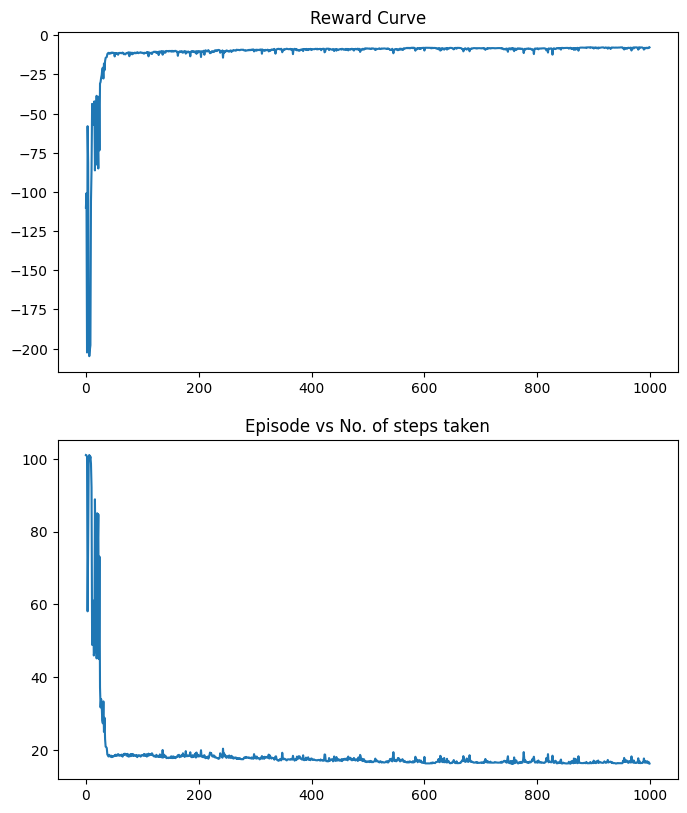

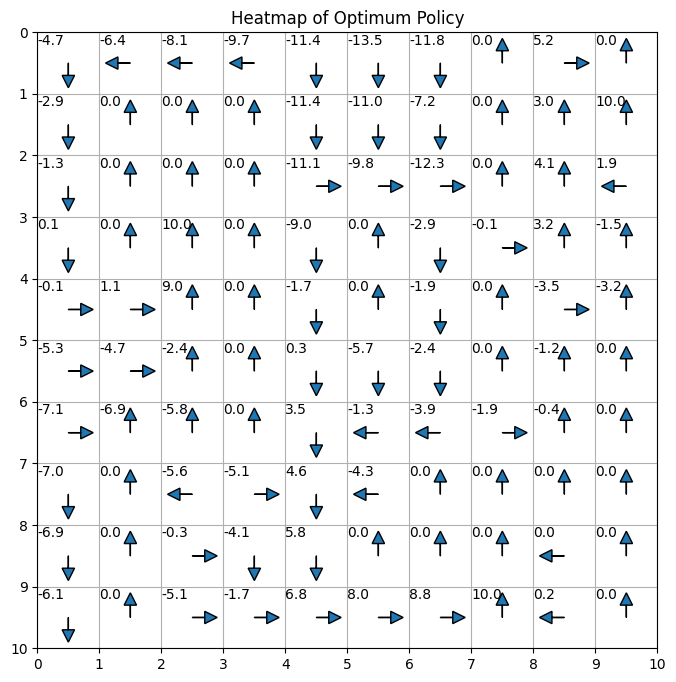

In [ ]:
#Configuration set
wind = False
p = 1
start = [0,4]
exploreMethod = 'e-greedy'
algo = 'sarsa'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()


##Analysis
**Description of the environment**
1. Algorithm used is SARSA, which means it is an Onlicy Policy search method, with epsilon greedy actions taken for both exploring the state and also to calculate value.
2. Wind is False and p = 1, which means the actions taken result in reasonably deterministic transitions.
3. We start at [0,4] which makes it quite likely to reach any of the goal states as they are almost equidistant.
4. Epsilon greedy is used, which means there is constant exploration through out

**Hyper-parameter analysis**
1. The best alpha is 1.0
2. The best gamma is 1.0
3. The best epsilon is 0.001

The above hyper parameters suggest, the algorithm has been quite greedy in order to maximise undiscounted reward. Given we are comparing undiscounted rewards, the algorithm seems to prefer an undiscounted gamma. Lowest epsilon has been chosen among the available options, showing the greediness.

**Reward Curve analysis**
1. The reward has very quickly converged within 100 episodes.
2. The reward is also maximised close to 0, which is fair considering the distance of the starting state.

**No of steps curve analysis**
1. The no.of steps has very quickly converged within 100 episodes to about 20 time steps, which the optimum to any goal state.

**Visit count heatmap analysis**
1. With almost a greedy search, the algorithm has explored path to all the goal states, however, the best parameters, seems to prefer the goal state at [0,9] more than [8,7]. This can be seen the heatmap of visits. One interesting observation here is that the path seems to be frequented through the bad state at [1,9] more than a direct route via [0,8]. This could be because of the probabilitistic transition with SARSA taking a less risky route than repeatedly hitting a blocked state.

**Learnt policy analysis**
1. *Policy towards [0,9]*
This goal states seems to be the prefered direction evidenced by the number of visits. However, the convergence doesnt seem to have happened clearly at [2,6], [6,6], where the policy seems to point away from the above goal state.

2. *Policy towards [2,2]*
Except for the start state, the policy towards this goal is correct and points to the goal state. It has learnt the directions well.

3. *Policy towards [8,7]*
Except [2,4} the policy points in the right direction for all states to reach this goal. And it is showing the shortest path

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have been preferred in some cases.

### (2) Configuration id SARSA-2

#### Configuration Parameters
Learning algorithm = SARSA

Wind = False

Start State = [0,4]

Value of $p$ = 1

Exploration strategy = Softmax

<IPython.core.display.Javascript object>

<ipython-input-11-38229ae5e193>:27: RuntimeWarning:

overflow encountered in exp

<ipython-input-11-38229ae5e193>:28: RuntimeWarning:

overflow encountered in exp

<ipython-input-11-38229ae5e193>:28: RuntimeWarning:

invalid value encountered in divide



Best Hyper-parameters
The best alpha is 1.0
The best gamma is 1.0
The best epsilon is 0
The best tau is 0.1 
 
--------------------------------------------------------


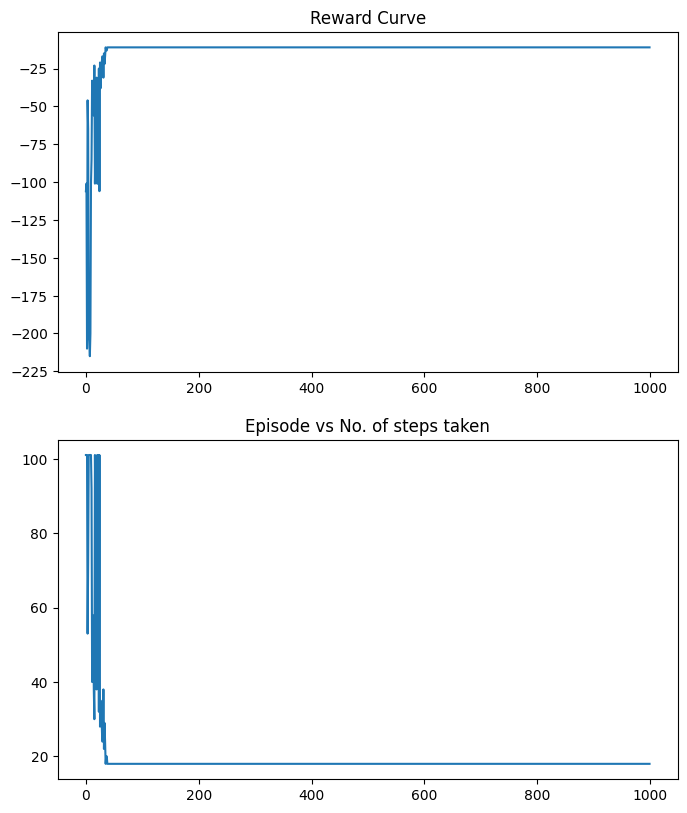

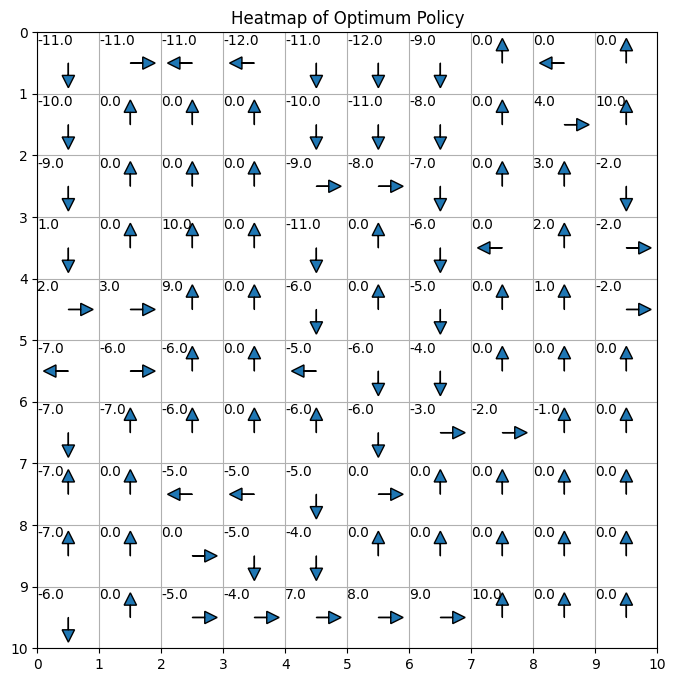

In [ ]:
#Configuration set
wind = False
p = 1
start = [0,4]
exploreMethod = 'softmax'
algo = 'sarsa'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()


##Analysis
**Description of the environment**
1. Algorithm used is SARSA, which means it is an Onlicy Policy search method, with softmax actions taken for both exploring the state and also to calculate value.
2. Wind is False and p = 1, which means the actions taken result in reasonably deterministic transitions.
3. We start at [0,4] which makes it quite likely to reach any of the goal states as they are almost equidistant.
4. Softmax is used, which means, preference would be given to actions with probability of giving higher value.

**Hyper-parameter analysis**
1. The best alpha is 1.0
2. The best gamma is 1.0
3. The best tau is 0.1

Given we are comparing undiscounted rewards, the algorithm seems to prefer an undiscounted gamma. Tau chosen to anneal the exploration is 0.1 which means, the exploration is conservative. Given softmax anyway maximises based on reward, it actually is greedy w.r.t values.

**Reward Curve analysis**
1. The reward has very quickly converged within 100 episodes.
2. However, the reward is not fully maximised and is hovering at a lower reward of -20. This is could be because, Softmax tends to explore much lesser than epsilon greedy, except in the initial stages.

**No of steps curve analysis**
1. The no.of steps has very quickly converged within 100 episodes to about 20 time steps, which the optimum to any goal state.

**Visit count heatmap analysis**
1. With relatively quick convergence to an "pre-determined" optimal action, softmax has not explored much and has stuck towards reaching the goal at [0,9]. There has been relatively no visits to other goal states. More than 90% of the visits have been towards [0,9] goal state.

**Learnt policy analysis**
1. *Policy towards [0,9]*
As this goal has been explored the most, the path learnt to this goal is very clear.

2. *Policy towards [2,2]*
Policy learnt towards this goal is not ideal in some of the states. That is a result of fewer exploration of this path. [0,1] is not pointing in the ideal direction.

3. *Policy towards [8,7]*
Policy learnt towards this goal is not ideal in some of the states. That is a result of fewer exploration of this path. [5,4] is not pointing in the ideal direction.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have been preferred towards [0,9], largely because of the stochastic nature of transitions.

### (3) Configuration id SARSA-3

#### Configuration Parameters
Learning algorithm = SARSA

Wind = True

Start State = [0,4]

Value of $p$ = 1

Exploration strategy = Epsilon Greedy

<IPython.core.display.Javascript object>

Best Hyper-parameters
The best alpha is 1.0
The best gamma is 0.9
The best epsilon is 0.001
The best tau is 0 
 
--------------------------------------------------------


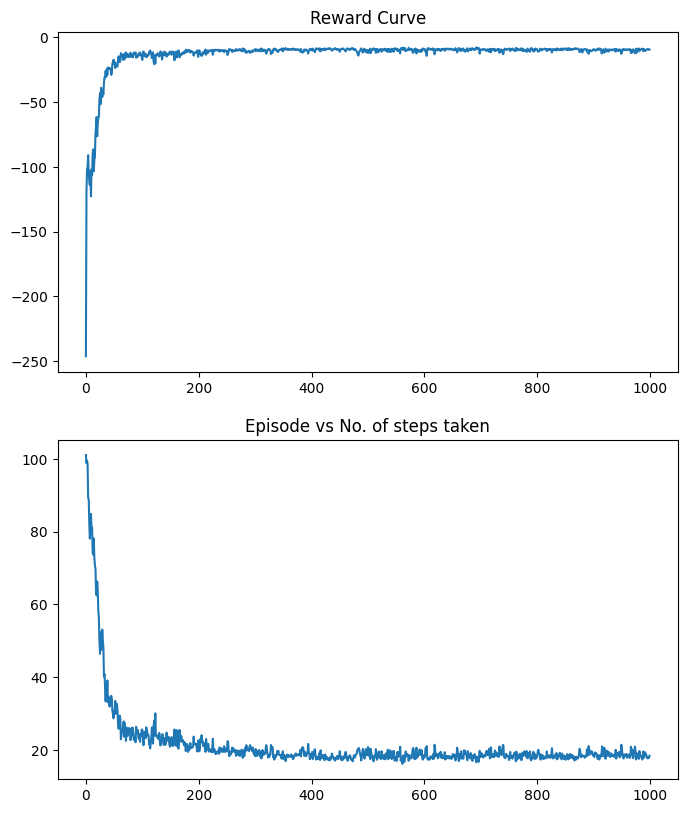

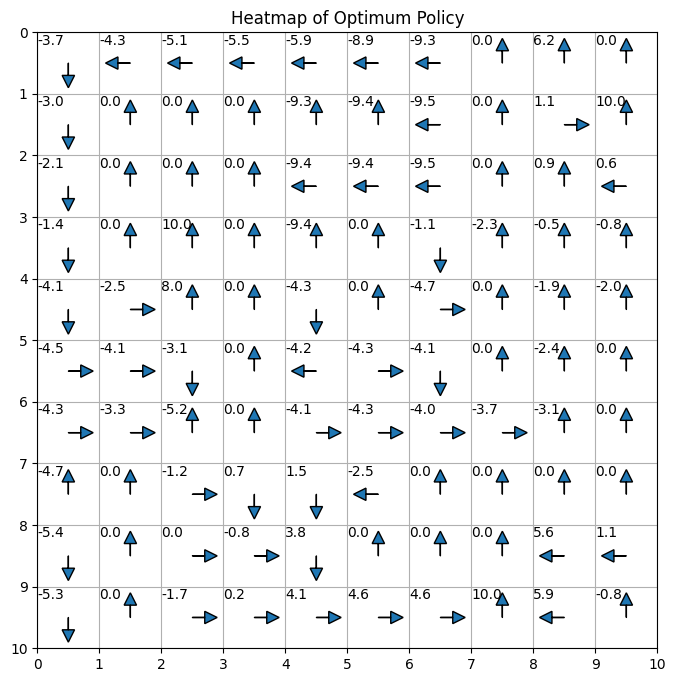

In [ ]:
#Configuration set
wind = True
p = 1
start = [0,4]
exploreMethod = 'e-greedy'
algo = 'sarsa'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()


##Analysis
**Description of the environment**
1. Algorithm used is SARSA, which means it is an Onlicy Policy search method, with epsilon greedy actions taken for both exploring the state and also to calculate value.
2. Wind is True and p = 1, which means while the state transition will be reasonably deterministic, the cross wind effect will make the transition stochastic with cell shifting.
3. We start at [0,4] which makes it quite likely to reach any of the goal states as they are almost equidistant. However, the wind effect would mean, goals on the left side of the grid world will be easier to reach.

**Hyper-parameter analysis**
1. The best alpha is 1.0
2. The best gamma is 0.9
3. The best epsilon is 0.001

Given we are comparing undiscounted rewards, the algorithm seems to prefer a gamma of 0.9, which is quite close to an undiscounted reward. The training seems to be almost greedy with respect to Q as can be seen in a very low epsilon value.

**Reward Curve analysis**
1. The reward has very quickly converged within 100 episodes.
2. The average reward is close to 0, which is maximal given the circumstances.

**No of steps curve analysis**
1. The no.of steps has very quickly converged within 100 episodes to about 20 time steps, which the optimum to any goal state. However, given the wind factor, we can see that the number of time steps is quite volatile due to the stochasticity.

**Visit count heatmap analysis**
1. Due to the wind factor, the overwhelming number of exploration has been towards [2,2] goal state. This is expected, due to leftward shift of transitions due to the wind. While other goal states have been explored, it has been minimal.

**Learnt policy analysis**
1. *Policy towards [0,9]*
The policy is complete undeterministic towardds this goal as expected. There is no clear policy towards this goal

2. *Policy towards [2,2]*
Policy is well learnt towards this goal and every state in the path has a clear direction from the start state

3. *Policy towards [8,7]*
Policy learnt towards this goal is not ideal in some of the states. That is a result of fewer exploration of this path. However, it has been better than goal [0,9]

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have been preferred towards [2,2], largely because of the stochastic nature of transitions.

### (4) Configuration id SARSA-4

#### Configuration Parameters
Learning algorithm = SARSA

Wind = True

Start State = [0,4]

Value of $p$ = 1

Exploration strategy = Softmax

<IPython.core.display.Javascript object>

<ipython-input-7-38229ae5e193>:27: RuntimeWarning:

overflow encountered in exp

<ipython-input-7-38229ae5e193>:28: RuntimeWarning:

overflow encountered in exp

<ipython-input-7-38229ae5e193>:28: RuntimeWarning:

invalid value encountered in divide



Best Hyper-parameters
The best alpha is 1.0
The best gamma is 0.9
The best epsilon is 0
The best tau is 2 
 
--------------------------------------------------------


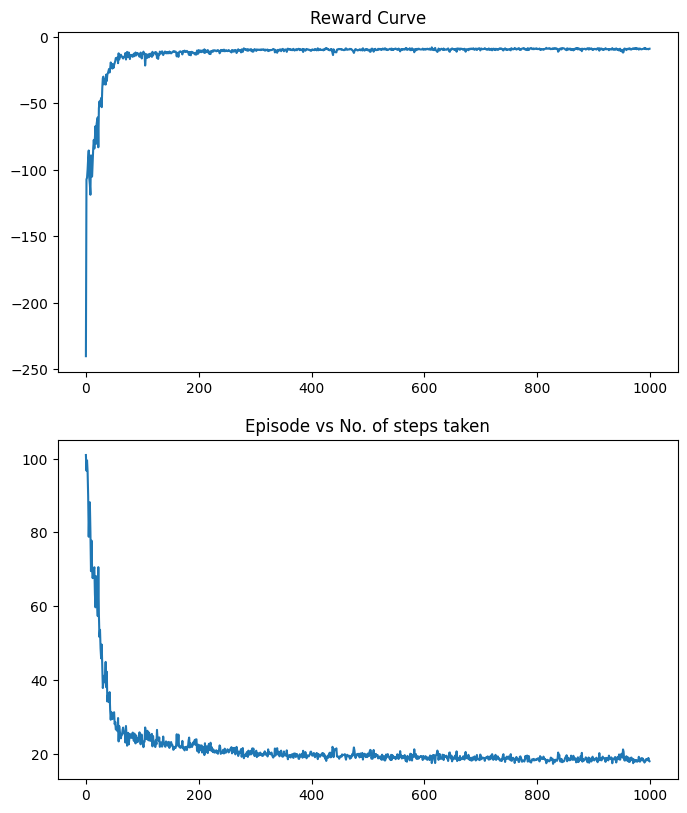

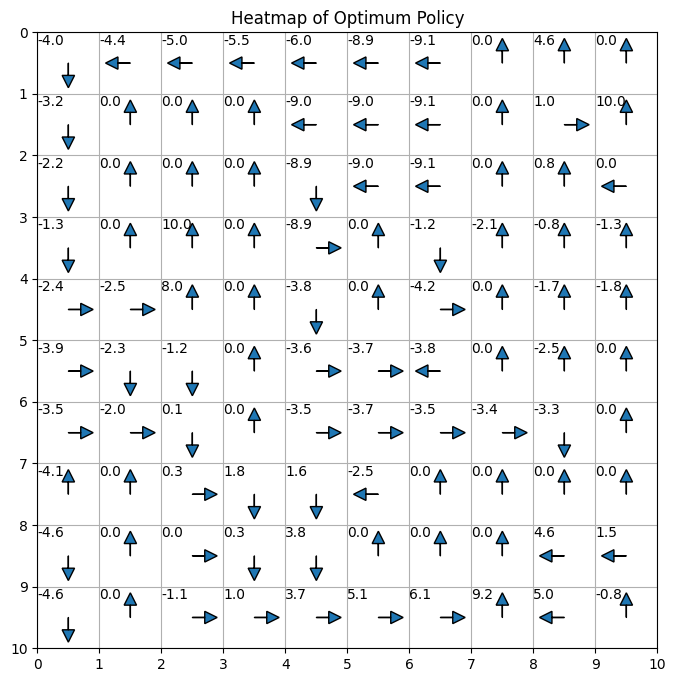

In [ ]:
#Configuration set
wind = True
p = 1
start = [0,4]
exploreMethod = 'softmax'
algo = 'sarsa'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()

##Analysis
**Description of the environment**
1. Algorithm used is SARSA, which means it is an Onlicy Policy search method, with softmax actions taken for both exploring the state and also to calculate value.
2. Wind is True and p = 1, which means while the state transition will be reasonably deterministic, the cross wind effect will make the transition stochastic with cell shifting.
3. We start at [0,4] which makes it quite likely to reach any of the goal states as they are almost equidistant. However, the wind effect would mean, goals on the left side of the grid world will be easier to reach.

**Hyper-parameter analysis**
1. The best alpha is 1.0
2. The best gamma is 0.9
3. The best tau is 2

Given we are comparing undiscounted rewards, the algorithm seems to prefer a gamma of 0.9, which is quite close to an undiscounted reward. The training seems to be almost greedy with respect to Q as can be seen with a high tau of 2.

**Reward Curve analysis**
1. The reward has very quickly converged within 100 episodes.
2. The average reward is close to 0, which is maximal given the circumstances.

**No of steps curve analysis**
1. The no.of steps has very quickly converged within 100 episodes to about 20 time steps, which the optimum to any goal state. However, given the wind factor, we can see that the number of time steps is quite volatile due to the stochasticity.

**Visit count heatmap analysis**
1. Due to the wind factor, the overwhelming number of exploration has been towards [2,2] goal state. This is expected, due to leftward shift of transitions due to the wind. While other goal states have been explored, it has been minimal.

**Learnt policy analysis**
1. *Policy towards [0,9]*
The policy is complete undeterministic towardds this goal as expected. There is no clear policy towards this goal

2. *Policy towards [2,2]*
Policy is well learnt towards this goal and every state in the path has a clear direction from the start state

3. *Policy towards [8,7]*
Policy learnt towards this goal is not ideal in some of the states. That is a result of fewer exploration of this path. However, it has been better than goal [0,9]. Also, path to this goal has been explored more than epsilon greedy, probably because of the softmax with a high tau exploring more in this case.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have been preferred towards [2,2], largely because of the stochastic nature of transitions.

### (5) Configuration id SARSA-5

#### Configuration Parameters
Learning algorithm = SARSA

Wind = False

Start State = [3,6]

Value of $p$ = 1

Exploration strategy = Epsilon Greedy

<IPython.core.display.Javascript object>

Best Hyper-parameters
The best alpha is 1.0
The best gamma is 0.9
The best epsilon is 0.001
The best tau is 0 
 
--------------------------------------------------------


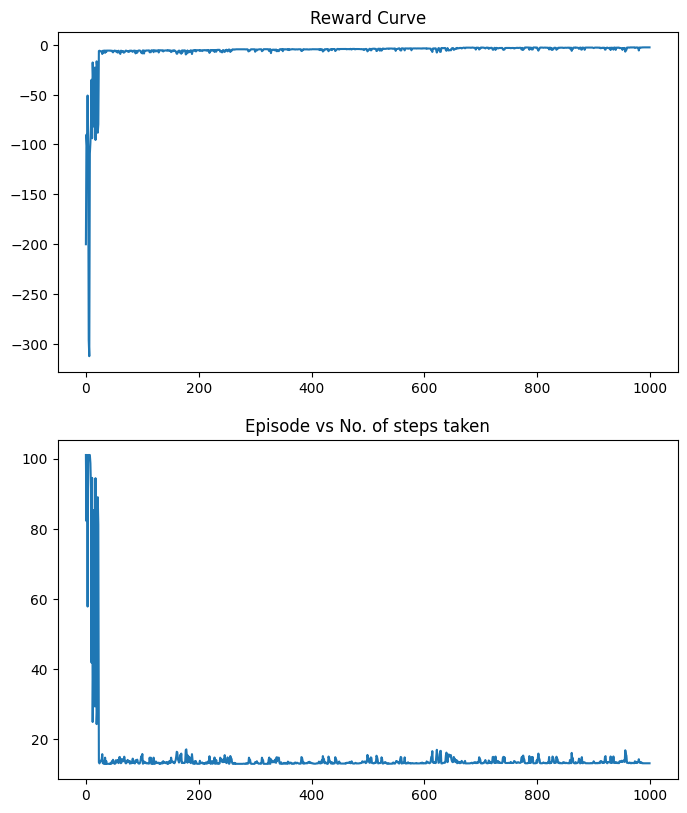

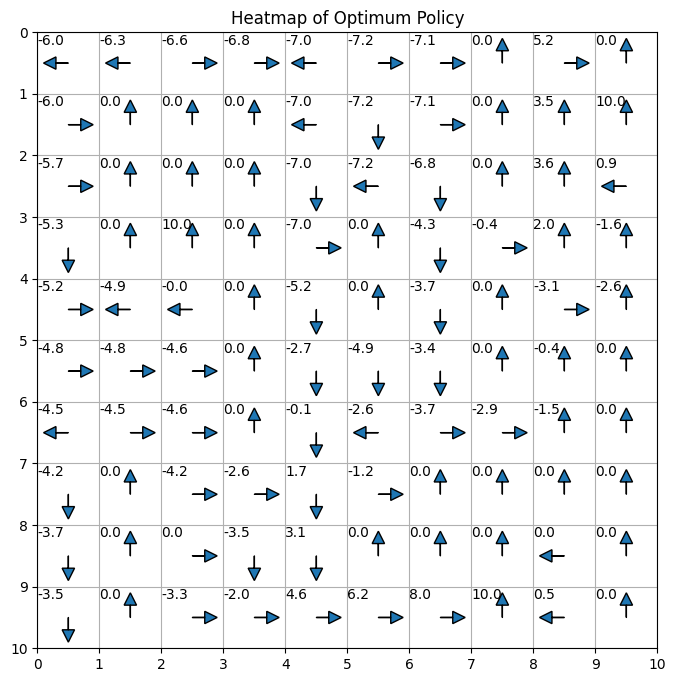

In [ ]:
#Configuration set
wind = False
p = 1
start = [3,6]
exploreMethod = 'e-greedy'
algo = 'sarsa'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()


##Analysis
**Description of the environment**
1. Algorithm used is SARSA, which means it is an Onlicy Policy search method, with epsilon greedy actions taken for both exploring the state and also to calculate value.
2. Wind is False and p = 1, which means while the state transition will be reasonably deterministic.
3. We start at [3,6] which is relatively closer to [0,9] and [8,7].

**Hyper-parameter analysis**
1. The best alpha is 1.0
2. The best gamma is 0.9
3. The best epsilon is 0.001

Given we are comparing undiscounted rewards, the algorithm seems to prefer a gamma of 0.9, which is quite close to an undiscounted reward. The training seems to be almost greedy with respect to Q as can be seen in a very low epsilon value of 0.001.

**Reward Curve analysis**
1. The reward has very quickly converged within 100 episodes.
2. The average reward is close to 0, which is maximal given the circumstances.

**No of steps curve analysis**
1. The no.of steps has very quickly converged within 100 episodes to less than 10 time steps, which the optimum to any goal state.

**Visit count heatmap analysis**
1. The training seems to prefer goal [0,9] over [8,7] as we can observe significantly higher number of visits are in that region.

**Learnt policy analysis**
1. *Policy towards [0,9]*
The policy is quite deterministic and shows a clear path to the goal. An interesting contrast to the earlier starting point [0,4] is that as the start state gets closer to the goal state, the path seems more clearly defined avoiding bad states with higher penalty. This can be seen in this too, the policy nicely avoids a bad state.

2. *Policy towards [2,2]*
Policy is reasonably accurate for this goal, except for a common point where there is preference for [0,9].

3. *Policy towards [8,7]*
Policy is not learnt very well for this goal, as the start state is quite far off from this state.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have been preferred towards [2,2], largely because of the stochastic nature of transitions.

### (6) Configuration id SARSA-6

#### Configuration Parameters
Learning algorithm = SARSA

Wind = False

Start State = [3,6]

Value of $p$ = 1

Exploration strategy = Softmax

<IPython.core.display.Javascript object>

<ipython-input-8-38229ae5e193>:27: RuntimeWarning:

overflow encountered in exp

<ipython-input-8-38229ae5e193>:28: RuntimeWarning:

overflow encountered in exp

<ipython-input-8-38229ae5e193>:28: RuntimeWarning:

invalid value encountered in divide



Best Hyper-parameters
The best alpha is 1.0
The best gamma is 1.0
The best epsilon is 0
The best tau is 0.1 
 
--------------------------------------------------------


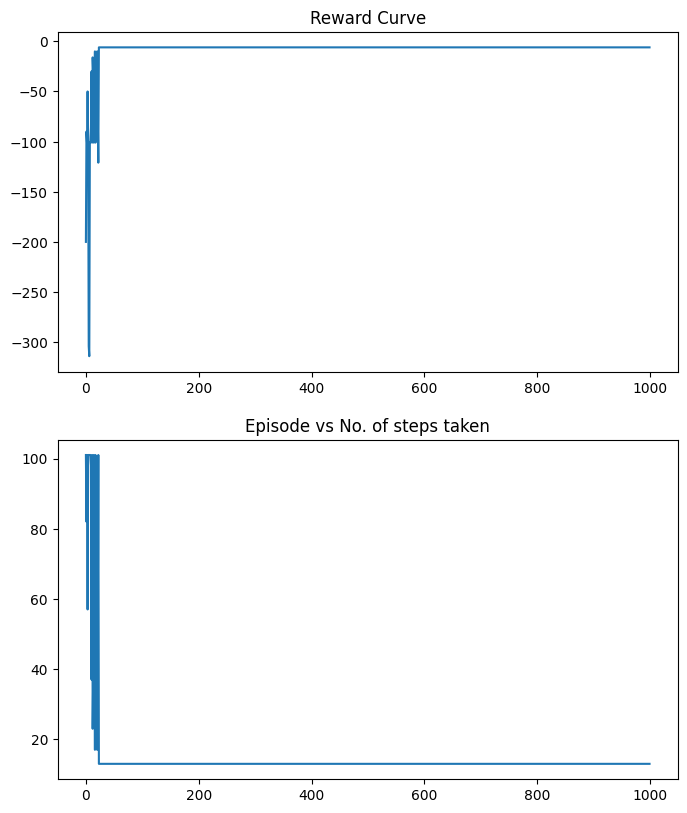

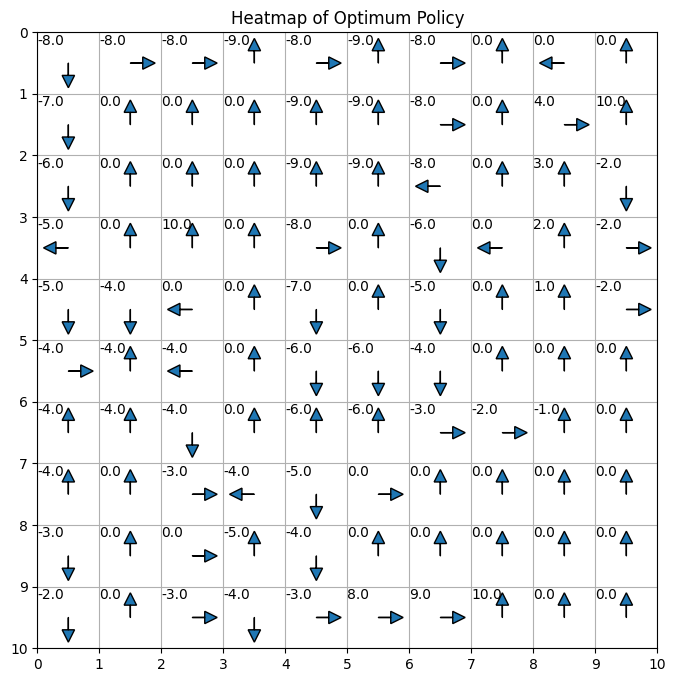

In [ ]:
#Configuration set
wind = False
p = 1
start = [3,6]
exploreMethod = 'softmax'
algo = 'sarsa'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()


##Analysis
**Description of the environment**
1. Algorithm used is SARSA, which means it is an Onlicy Policy search method, with softmax actions taken for both exploring the state and also to calculate value.
2. Wind is False and p = 1, which means while the state transition will be reasonably deterministic.
3. We start at [3,6] which is relatively closer to [0,9] and [8,7].

**Hyper-parameter analysis**
1. The best alpha is 1.0
2. The best gamma is 1.0
3. The best tau is 0.1

Given we are comparing undiscounted rewards, the algorithm seems to prefer a gamma of 1, which is quite close to an undiscounted reward. The training seems to be greedy as one can see with a low tau

**Reward Curve analysis**
1. The reward has very quickly converged within 100 episodes.
2. The average reward is close to 0, which is maximal given the circumstances.

**No of steps curve analysis**
1. The no.of steps has very quickly converged within 100 episodes to less than 10 time steps, which the optimum to any goal state.

**Visit count heatmap analysis**
1. The training seems to prefer goal [0,9] over [8,7] as we can observe significantly higher number of visits are in that region.

**Learnt policy analysis**
1. *Policy towards [0,9]*
The policy is quite deterministic and shows a clear path to the goal. However, unlike epsilon greedy method for the same set up, softmax prefers going through the bad state at [1,9] instead of avoiding it. This could be because of the less exploration it tries to do.

2. *Policy towards [2,2]*
Unlike epsilon greedy, the policy towards this goal is not that well defined as it has been explored lesser.

3. *Policy towards [8,7]*
Policy is not learnt very well for this goal, as the start state is quite far off from this state.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have been preferred towards [2,2], largely because of the stochastic nature of transitions.

### (7) Configuration id SARSA-7

#### Configuration Parameters
Learning algorithm = SARSA

Wind = True

Start State = [3,6]

Value of $p$ = 1

Exploration strategy = Epsilon Greedy

<IPython.core.display.Javascript object>

Best Hyper-parameters
The best alpha is 1.0
The best gamma is 1.0
The best epsilon is 0.001
The best tau is 0 
 
--------------------------------------------------------


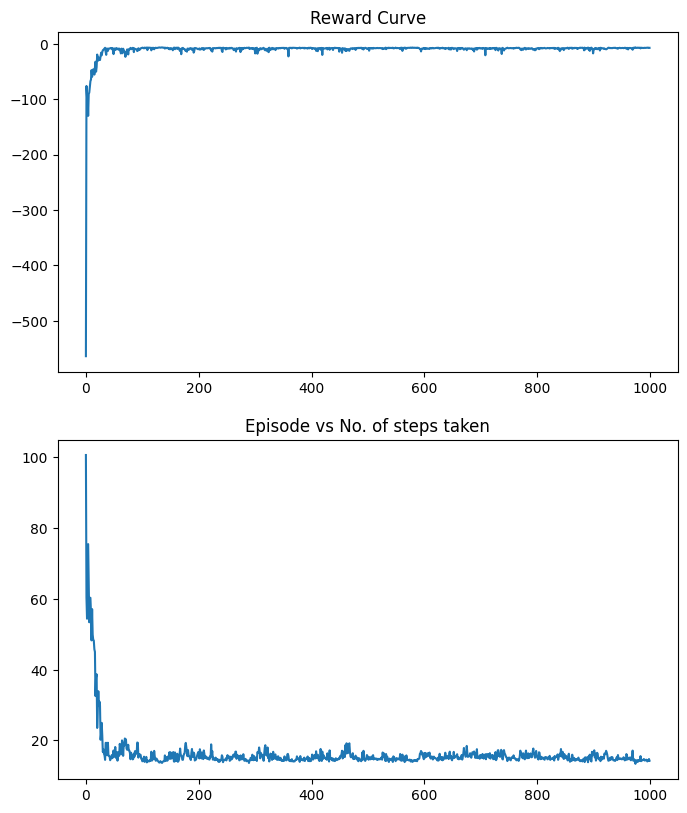

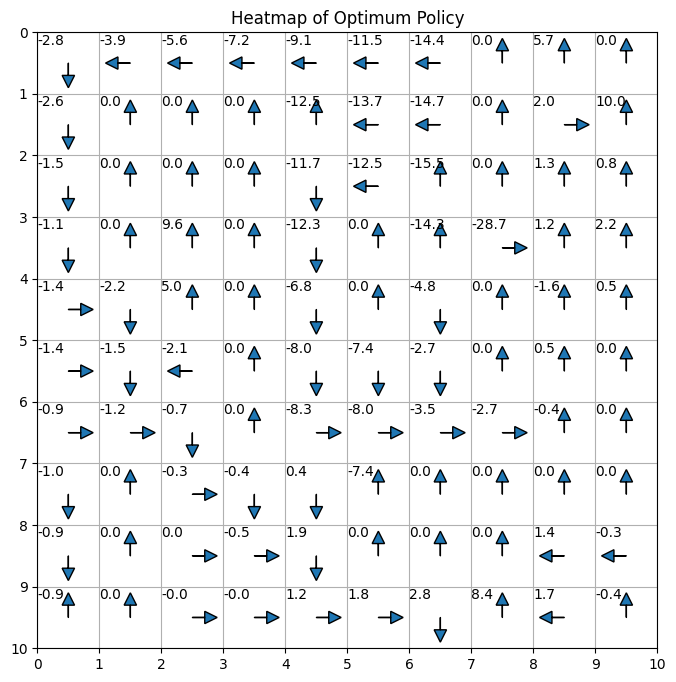

In [ ]:
#Configuration set
wind = True
p = 1
start = [3,6]
exploreMethod = 'e-greedy'
algo = 'sarsa'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()


##Analysis
**Description of the environment**
1. Algorithm used is SARSA, which means it is an Onlicy Policy search method, with epsilon greedy actions taken for both exploring the state and also to calculate value.
2. Wind is True and p = 1, which means while the state transition will be reasonably deterministic.
3. We start at [3,6] which is relatively closer to [0,9] and [8,7].

**Hyper-parameter analysis**
1. The best alpha is 1.0
2. The best gamma is 1.0
3. The best tau is 0.001

Given we are comparing undiscounted rewards, the algorithm seems to prefer a gamma of 1, which is quite close to an undiscounted reward. The training seems to be greedy as one can see with a low epsilon

**Reward Curve analysis**
1. The reward has very quickly converged within 100 episodes.
2. The average reward is close to 0, which is maximal given the circumstances.

**No of steps curve analysis**
1. The no.of steps has very quickly converged within 100 episodes to less than 20 time steps, which the optimum to any goal state.

**Visit count heatmap analysis**
1. The training seems to prefer goal [0,9] followed by [0,2] as we can observe significantly higher number of visits are in that region.

**Learnt policy analysis**
1. *Policy towards [0,9]*
The policy is quite deterministic and shows a clear path to the goal. However, unlike epsilon greedy method for the same set up without wind, this config prefers going through the bad state at [1,9] instead of avoiding it. **Also we can observe that even though there is wind impact, because [0,9] is a closer goal state, it is quickly attracted to that state" Goal [8,7] has obstacles and forbidden states to go through and hence is not preferred.

2. *Policy towards [2,2]*
Unlike epsilon greedy, the policy towards this goal is not that well defined as it has been explored lesser.

3. *Policy towards [8,7]*
Policy is not learnt properly for this goal, as the start state is quite far off from this state.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have been preferred towards [2,2], largely because of the stochastic nature of transitions.

### (8) Configuration id SARSA-8

#### Configuration Parameters
Learning algorithm = SARSA

Wind = True

Start State = [3,6]

Value of $p$ = 1

Exploration strategy = Softmax

<IPython.core.display.Javascript object>

<ipython-input-8-38229ae5e193>:27: RuntimeWarning:

overflow encountered in exp

<ipython-input-8-38229ae5e193>:28: RuntimeWarning:

overflow encountered in exp

<ipython-input-8-38229ae5e193>:28: RuntimeWarning:

invalid value encountered in divide



Best Hyper-parameters
The best alpha is 1.0
The best gamma is 1.0
The best epsilon is 0
The best tau is 0.1 
 
--------------------------------------------------------


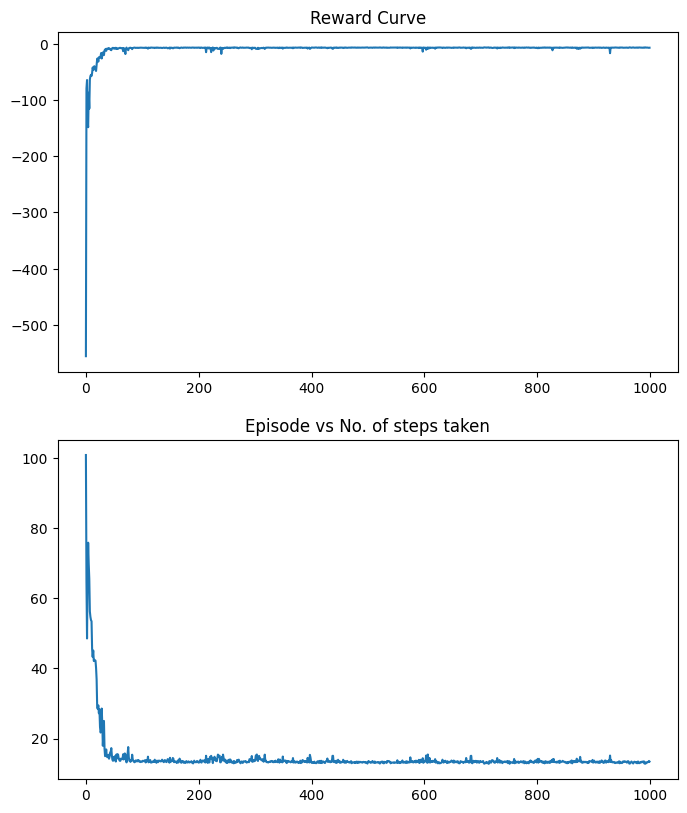

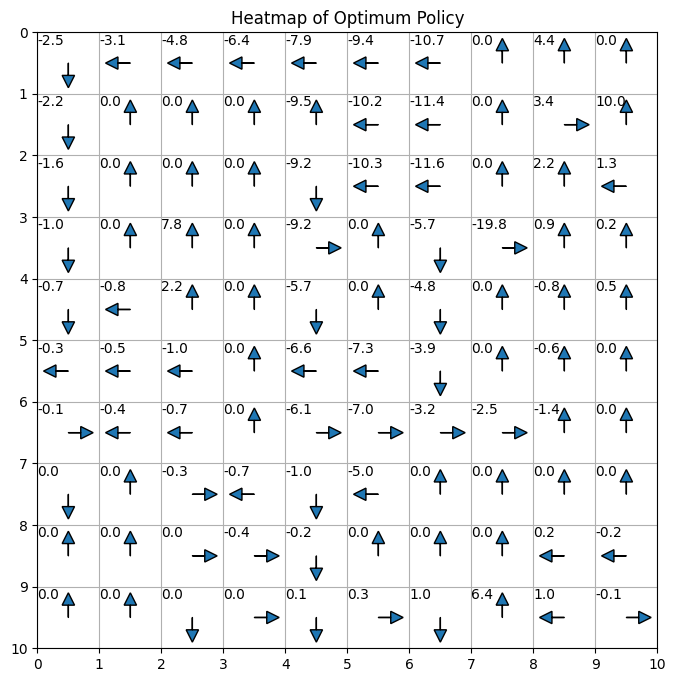

In [ ]:
#Configuration set
wind = True
p = 1
start = [3,6]
exploreMethod = 'softmax'
algo = 'sarsa'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()

##Analysis
**Description of the environment**
1. Algorithm used is SARSA, which means it is an Onlicy Policy search method, with softmax actions taken for both exploring the state and also to calculate value.
2. Wind is True and p = 1, which means while the state transition will be reasonably deterministic.
3. We start at [3,6] which is relatively closer to [0,9] and [8,7].

**Hyper-parameter analysis**
1. The best alpha is 1.0
2. The best gamma is 1.0
3. The best tau is 0.1

Given we are comparing undiscounted rewards, the algorithm seems to prefer a gamma of 1, which is quite close to an undiscounted reward. The training seems to be greedy as one can see with a low tau

**Reward Curve analysis**
1. The reward has very quickly converged within 100 episodes.
2. The average reward is close to 0, which is maximal given the circumstances.

**No of steps curve analysis**
1. The no.of steps has very quickly converged within 100 episodes to less than 20 time steps, which the optimum to any goal state.

**Visit count heatmap analysis**
1. The training seems to prefer goal [0,9]  as we can observe significantly higher number of visits are in that region. The other goal states were not even explored much.

**Learnt policy analysis**
1. *Policy towards [0,9]*
The policy is quite deterministic and shows a clear path to the goal. However, unlike epsilon greedy method for the same set up without wind, this config prefers going through the bad state at [1,9] instead of avoiding it. Softmax seems to exploit more towards this goal than equivalent epsilon greedy method.

2. *Policy towards [2,2]*
Unlike epsilon greedy, the policy towards this goal is not that well defined as it has been explored lesser.

3. *Policy towards [8,7]*
Policy is not learnt properly for this goal, as the start state is quite far off from this state.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have been preferred towards [2,2], largely because of the stochastic nature of transitions.

###(9) Configuration id Q-Learning-1

#### Configuration Parameters
Learning algorithm = Q-Learning

Wind = False

Start State = [0,4]

Value of $p$ = 1

Exploration strategy = Epsilon Greedy

<IPython.core.display.Javascript object>

Best Hyper-parameters
The best alpha is 1.0
The best gamma is 0.7
The best epsilon is 0.01
The best tau is 0 
 
--------------------------------------------------------


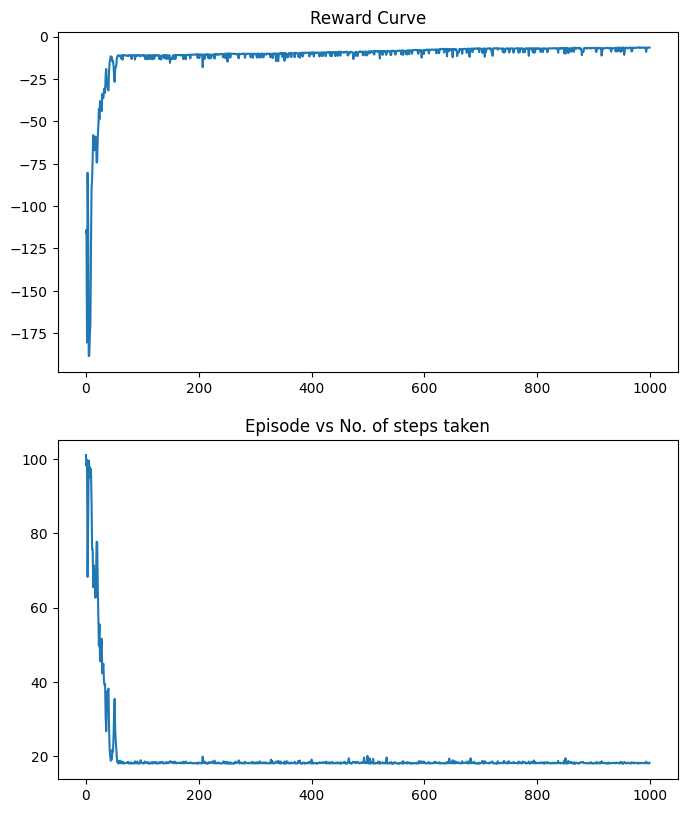

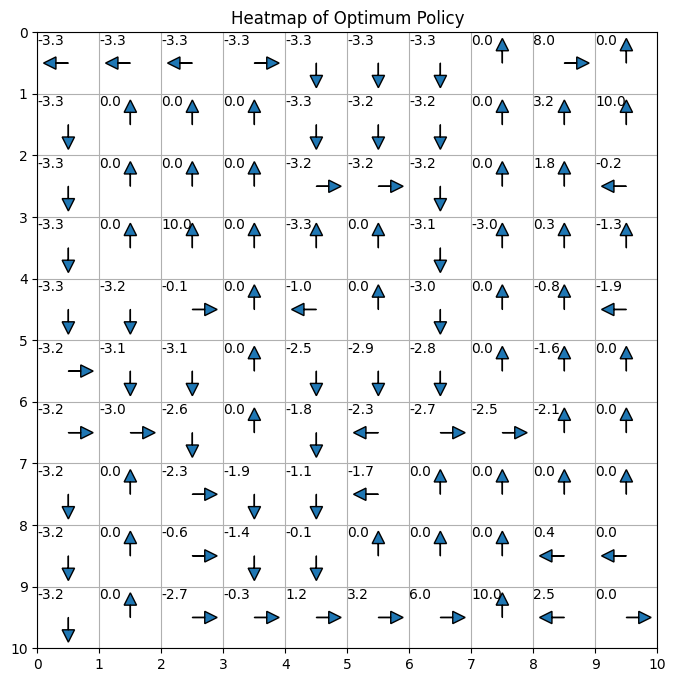

In [ ]:
#Configuration set
wind = False
p = 1
start = [0,4]
exploreMethod = 'e-greedy'
algo = 'q-learning'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()

##Analysis
**Description of the environment**
1. Algorithm used is Q-Learning, which means it is an Off Policy search method, with e-greedy actions taken for both exploring the state and and max of Q value taken for Q value learning.
2. Wind is False and p = 1, which means while the state transition will be reasonably deterministic.
3. We start at [0,4] which is equidistant to [0,9], [2,2] and [8,7].

**Hyper-parameter analysis**
1. The best alpha is 1.0
2. The best gamma is 0.7
3. The best epsilon is 0.01

Unlike SARSA generally, the gamma chosen is much lower at 0.7 indicating that discounted rewards seem to give a truer picture of the future rewards to be explored. Epsilon chosen is a moderate 0.01 as it balances exploitation and exploration. Q-learning is already greedy w.r.t Q values.

**Reward Curve analysis**
1. The reward has very quickly converged within 100 episodes.
2. The average reward is close to 0, which is maximal given the circumstances.

**No of steps curve analysis**
1. The no.of steps has very quickly converged within 100 episodes to less than 20 time steps, which the optimum to any goal state.

**Visit count heatmap analysis**
1. The training seems to prefer goal [0,9] over [7,8]  as we can observe significantly higher number of visits are in that region. However, there are sufficient visits towards [7,8] too.

**Learnt policy analysis**
1. *Policy towards [0,9]*
The policy path is quite clear towards this goal and unlike equivalent SARSA, Q-learning has found a path with higher reward through [0,8] instead of the bad state [1,9]. This is largely due to the off policy nature of Q-learning.

2. *Policy towards [2,2]*
The policy towards this goal is reasonably deterministic too as there have been sufficient exploration to this goal state too. Except for one divergence point betweent [0,9] and [2,2], all other states have a clear path.

3. *Policy towards [8,7]*
Policy is not well learnt as sufficient paths have not been explored.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have been avoided too


### (10) Configuration id Q-Learning - 2

#### Configuration Parameters
Learning algorithm = Q-Learning

Wind = False

Start State = [0,4]

Value of $p$ = 1

Exploration strategy = Softmax

<IPython.core.display.Javascript object>

<ipython-input-8-38229ae5e193>:27: RuntimeWarning:

overflow encountered in exp

<ipython-input-8-38229ae5e193>:28: RuntimeWarning:

overflow encountered in exp

<ipython-input-8-38229ae5e193>:28: RuntimeWarning:

invalid value encountered in divide



Best Hyper-parameters
The best alpha is 1.0
The best gamma is 1.0
The best epsilon is 0
The best tau is 0.1 
 
--------------------------------------------------------


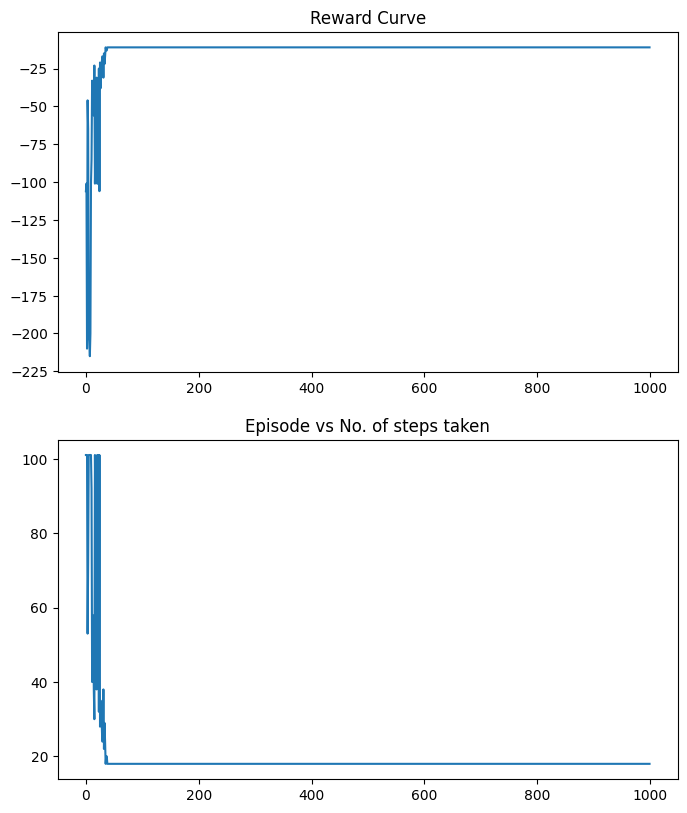

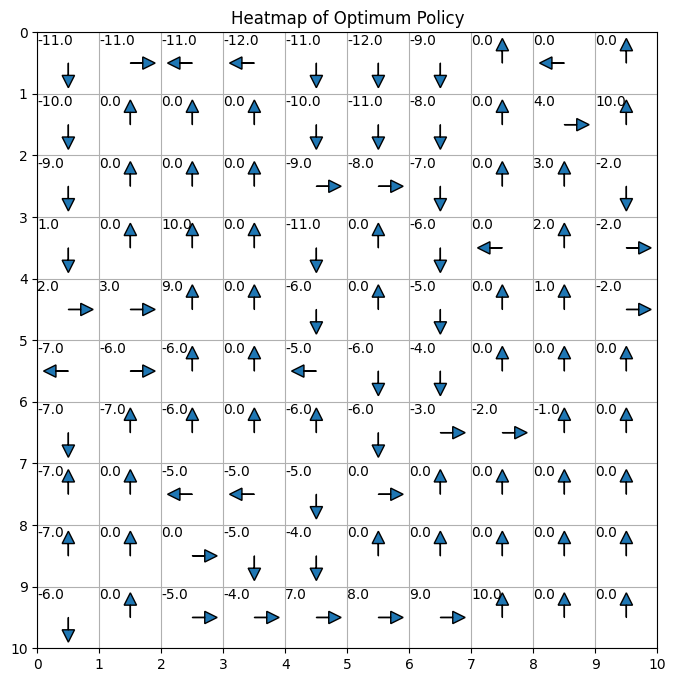

In [ ]:
#Configuration set
wind = False
p = 1
start = [0,4]
exploreMethod = 'softmax'
algo = 'q-learning'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()

##Analysis
**Description of the environment**
1. Algorithm used is Q-Learning, which means it is an Off Policy search method, with softmax actions taken for exploring the state and and max of Q value taken for Q value learning.
2. Wind is False and p = 1, which means while the state transition will be reasonably deterministic.
3. We start at [0,4] which is equidistant to [0,9], [2,2] and [8,7].

**Hyper-parameter analysis**
1. The best alpha is 1.0
2. The best gamma is 1.0
3. The best tau is 0.1

Highest gamma is chosen to take undiscounted rewards. A more moderate tau = 0.1 is chosen to ensure there is some exploration, but greedy most of the time.

**Reward Curve analysis**
1. The reward has very quickly converged within 100 episodes.
2. However, the average reward hovers around -20, which is not the most optimal reward. Softmax being greedy about the actions, has not been able to always find the most optimal path in terms of aggregate reward.

**No of steps curve analysis**
1. The no.of steps has very quickly converged within 100 episodes to less than 20 time steps, which the optimum to any goal state.

**Visit count heatmap analysis**
1. Visits to [0,9] have dominated the training. Softmax being quite greedy on Q-value has not explored other paths much

**Learnt policy analysis**
1. *Policy towards [0,9]*
The policy path is quite clear towards this goal however, like SARSA with equivalent config, has chosen a path via the bad state [1,9] to the goal [0,9]

2. *Policy towards [2,2]*
Policy is not well learnt as sufficient paths have not been explored.

3. *Policy towards [8,7]*
Policy is not well learnt as sufficient paths have not been explored.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have been visited and included in the policy as it has not been exploratory.

### (11) Configuration id Q-Learning - 3

#### Configuration Parameters
Learning algorithm = Q Learning

Wind = False

Start State = [3,6]

Value of $p$ = 1

Exploration strategy = Epsilon Greedy

<IPython.core.display.Javascript object>

Best Hyper-parameters
The best alpha is 1.0
The best gamma is 0.7
The best epsilon is 0.01
The best tau is 0 
 
--------------------------------------------------------


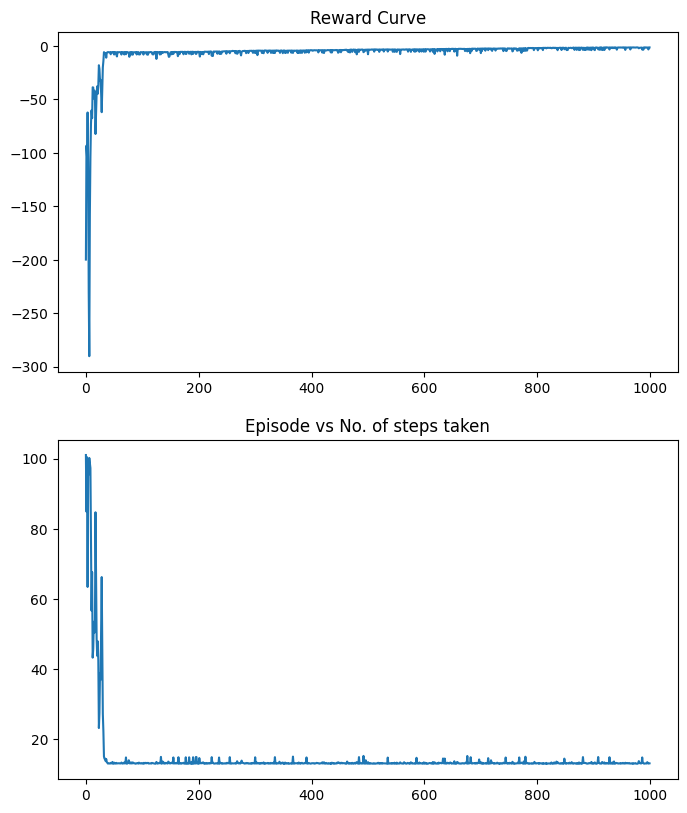

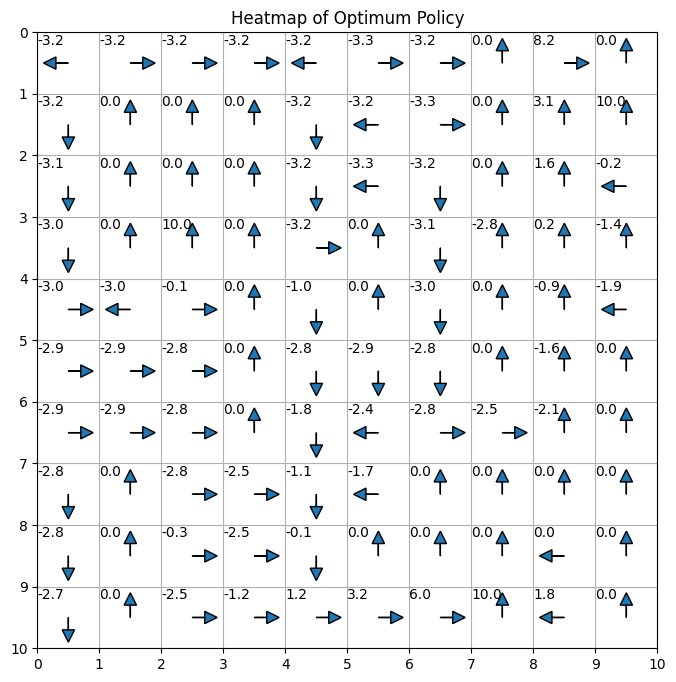

In [ ]:
#Configuration set
wind = False
p = 1
start = [3,6]
exploreMethod = 'e-greedy'
algo = 'q-learning'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()


##Analysis
**Description of the environment**
1. Algorithm used is Q-Learning, which means it is an Off Policy search method, with e-greedy actions taken for both exploring the state and and max of Q value taken for Q value learning.
2. Wind is False and p = 1, which means while the state transition will be reasonably deterministic.
3. We start at [3,6] which is equidistant to [0,9] and [8,7].

**Hyper-parameter analysis**
1. The best alpha is 1.0
2. The best gamma is 0.7
3. The best epsilon is 0.01

Unlike SARSA generally, the gamma chosen is much lower at 0.7 indicating that discounted rewards seem to give a truer picture of the future rewards to be explored. Epsilon chosen is a moderate 0.01 as it balances exploitation and exploration. Q-learning is already greedy w.r.t Q values.

**Reward Curve analysis**
1. The reward has very quickly converged within 100 episodes.
2. The average reward is close to 0, which is maximal given the circumstances.

**No of steps curve analysis**
1. The no.of steps has very quickly converged within 100 episodes to less than 20 time steps, which the optimum to any goal state.

**Visit count heatmap analysis**
1. The training seems to prefer goal [0,9] over [7,8]  as we can observe significantly higher number of visits are in that region. However, there are sufficient visits towards [7,8] too.

**Learnt policy analysis**
1. *Policy towards [0,9]*
The policy path is quite clear towards this goal and unlike equivalent SARSA, Q-learning has found a path with higher reward through [0,8] instead of the bad state [1,9]. This is largely due to the off policy nature of Q-learning.

2. *Policy towards [2,2]*
The policy towards this goal is reasonably deterministic too as there have been sufficient exploration to this goal state too. Except for one divergence point betweent [0,9] and [2,2], all other states have a clear path.

3. *Policy towards [8,7]*
Policy is not well learnt as sufficient paths have not been explored.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have been avoided too


### (12) Configuration id Q-Learning - 4

#### Configuration Parameters
Learning algorithm = Q Learning

Wind = False

Start State = [3,6]

Value of $p$ = 1

Exploration strategy = Softmax

<IPython.core.display.Javascript object>

<ipython-input-7-38229ae5e193>:27: RuntimeWarning:

overflow encountered in exp

<ipython-input-7-38229ae5e193>:28: RuntimeWarning:

overflow encountered in exp

<ipython-input-7-38229ae5e193>:28: RuntimeWarning:

invalid value encountered in divide



Best Hyper-parameters
The best alpha is 1.0
The best gamma is 1.0
The best epsilon is 0
The best tau is 0.1 
 
--------------------------------------------------------


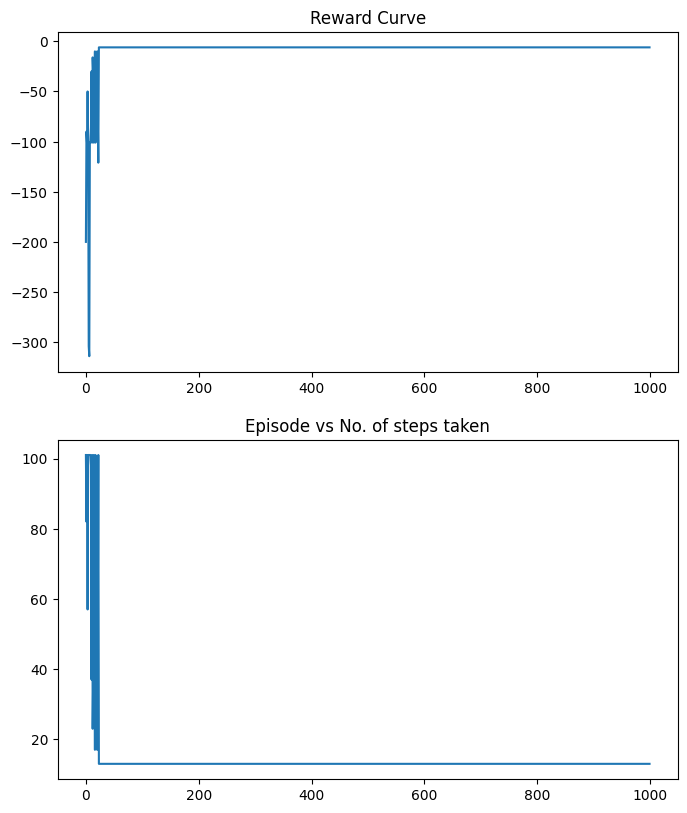

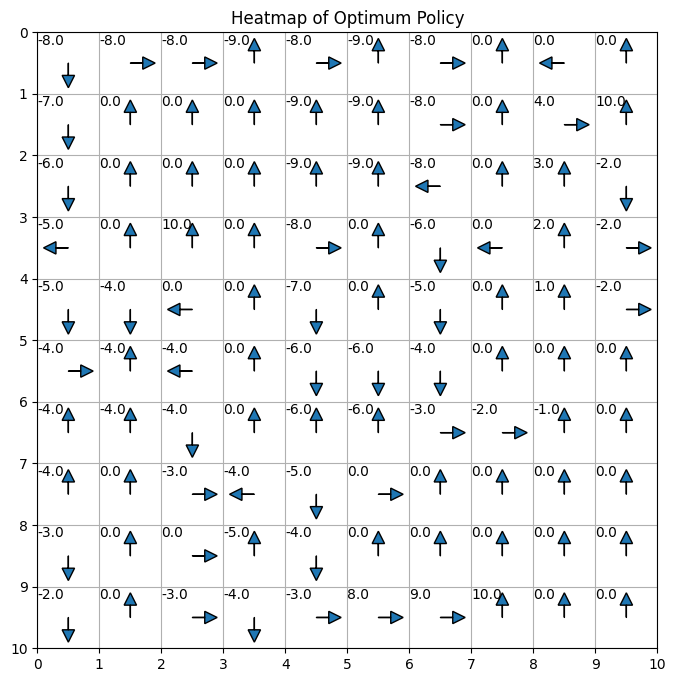

In [ ]:
#Configuration set
wind = False
p = 1
start = [3,6]
exploreMethod = 'softmax'
algo = 'q-learning'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()


##Analysis
**Description of the environment**
1. Algorithm used is Q-Learning, which means it is an Off Policy search method, with softmax actions taken for exploring the state and and max of Q value taken for Q value learning.
2. Wind is False and p = 1, which means while the state transition will be reasonably deterministic.
3. We start at [3,6] which is equidistant to [0,9] and [8,7].

**Hyper-parameter analysis**
1. The best alpha is 1.0
2. The best gamma is 1.0
3. The best tau is 0.1

Highest gamma is chosen to take undiscounted rewards. A more moderate tau = 0.1 is chosen to ensure there is some exploration, but greedy most of the time.

**Reward Curve analysis**
1. The reward has very quickly converged within 100 episodes.
2. Unlike the starting state of [0,4] where the rewards were not close to 0, in this case, start from [3,6], Softmax is able to find an optimal path with reward close to 0, which is optimal.

**No of steps curve analysis**
1. The no.of steps has very quickly converged within 100 episodes to less than 20 time steps, which the optimum to any goal state.

**Visit count heatmap analysis**
1. Visits to [0,9] have dominated the training. Softmax being quite greedy on Q-value has not explored other paths much

**Learnt policy analysis**
1. *Policy towards [0,9]*
The policy path is quite clear towards this goal however, like SARSA with equivalent config, has chosen a path via the bad state [1,9] to the goal [0,9]

2. *Policy towards [2,2]*
Policy is not well learnt as sufficient paths have not been explored.

3. *Policy towards [8,7]*
Policy is not well learnt as sufficient paths have not been explored.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have been visited and included in the policy as it has not been exploratory.

### (13) Configuration id Q-Learning - 5

#### Configuration Parameters
Learning algorithm = Q Learning

Wind = False

Start State = [0,4]

Value of $p$ = 0.7

Exploration strategy = Epsilon Greedy

<IPython.core.display.Javascript object>

Best Hyper-parameters
The best alpha is 0.1
The best gamma is 1.0
The best epsilon is 0.001
The best tau is 0 
 
--------------------------------------------------------


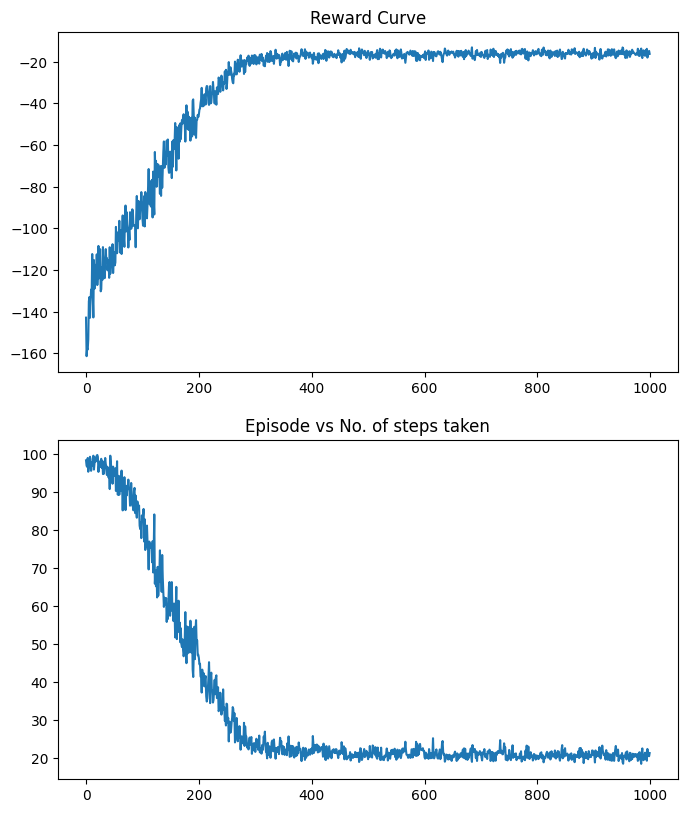

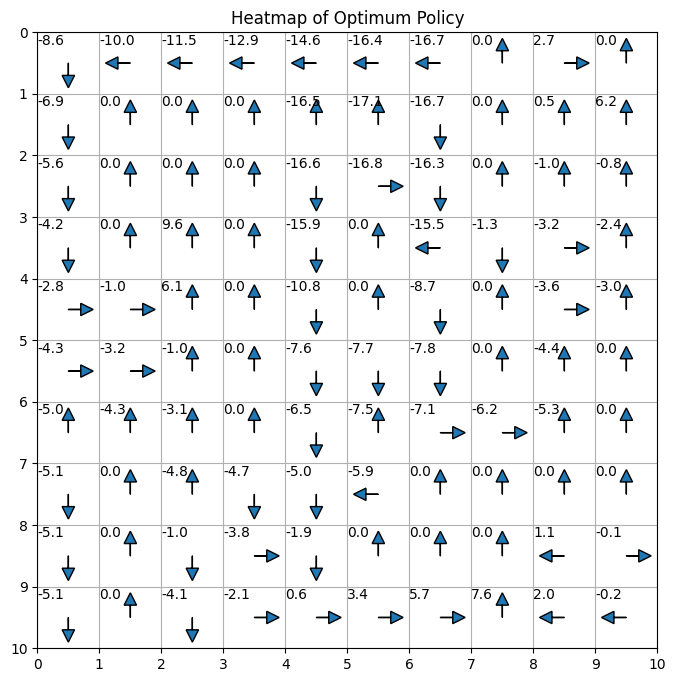

In [ ]:
#Configuration set
wind = False
p = 0.7
start = [0,4]
exploreMethod = 'e-greedy'
algo = 'q-learning'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()


##Analysis
**Description of the environment**
1. Algorithm used is Q-Learning, which means it is an Off Policy search method, with e-greedy actions taken for both exploring the state and and max of Q value taken for Q value learning.
2. Wind is False and p = 0.7, which means while the state transition can be quite stochastic.
3. We start at [0,4] which is equidistant to [0,9], [2,2] and [8,7].

**Hyper-parameter analysis**
1. The best alpha is 0.1
2. The best gamma is 1.0
3. The best epsilon is 0.001

With a higher level of stochasticity (p = 0.7), the learning has clearly chosen a smaller alpha in order to slow down the learning process and make adjustments at the right place. It has chosen an undiscounted reward with gamma = 1 and a fairly greedy approach with epsilon = 0.001


**Reward Curve analysis**
1. As one can guess, with stochasticity, the learning takes longer to converge and in this case it has taken over 200 episodes to start converging.
2. The average reward is still not optimal with average rewards around -20.
3. Even after reasonable convergence, there is fair bit of volatility owing the p-value.

**No of steps curve analysis**
1. Just like rewards, no. of steps is also slower to converge taking more than 200 episodes to settle at an average steps of 20 eventually.

**Visit count heatmap analysis**
1. With a lower p = 0.7, the training has explored left side of the grid more often and has seem to have found the goal state [2,2] more consistently than any of the other goals. One can also above that a lot of the previously not so explored states have been explored in this configuration.

**Learnt policy analysis**
1. *Policy towards [0,9]*
As the training has overwhelmingly preferred [2,2], the policy towards this goal is not well defined.

2. *Policy towards [2,2]*
The policy towards this goal is reasonably deterministic too as there have been sufficient exploration to this goal state.

3. *Policy towards [8,7]*
Policy is not well learnt as sufficient paths have not been explored.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have bee visited too in this process


### (14) Configuration id Q-Learning - 6

#### Configuration Parameters
Learning algorithm = Q Learning

Wind = False

Start State = [0,4]

Value of $p$ = 0.7

Exploration strategy = Softmax

<IPython.core.display.Javascript object>

<ipython-input-7-38229ae5e193>:27: RuntimeWarning:

overflow encountered in exp

<ipython-input-7-38229ae5e193>:28: RuntimeWarning:

overflow encountered in exp

<ipython-input-7-38229ae5e193>:28: RuntimeWarning:

invalid value encountered in divide



Best Hyper-parameters
The best alpha is 0.1
The best gamma is 1.0
The best epsilon is 0
The best tau is 2 
 
--------------------------------------------------------


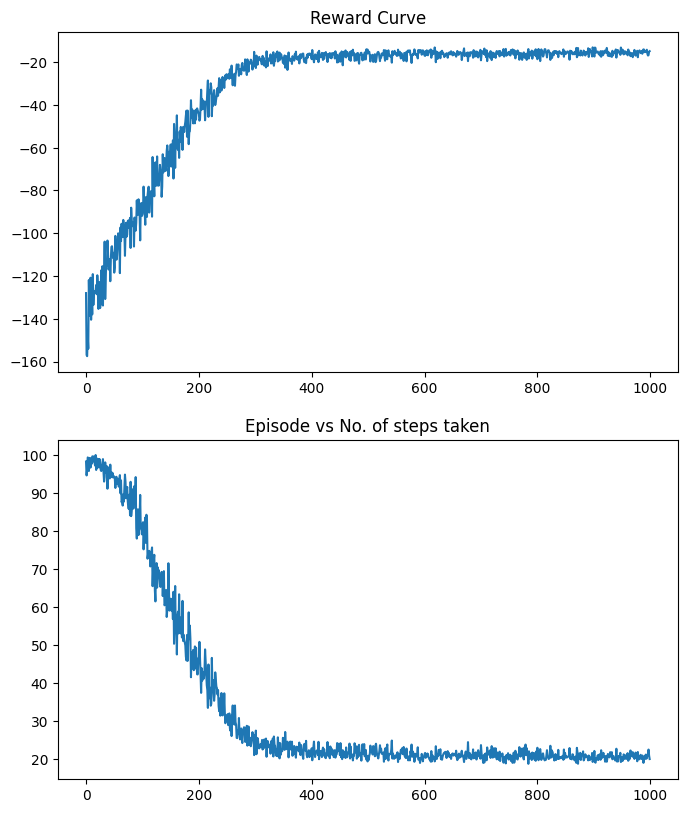

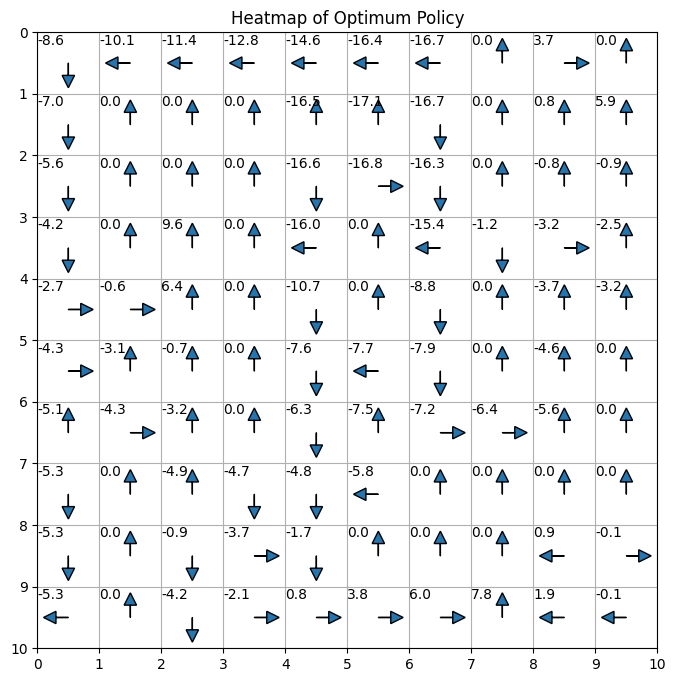

In [ ]:
#Configuration set
wind = False
p = 0.7
start = [0,4]
exploreMethod = 'softmax'
algo = 'q-learning'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()


##Analysis
**Description of the environment**
1. Algorithm used is Q-Learning, which means it is an Off Policy search method, with softmax actions taken for both exploring the state and and max of Q value taken for Q value learning.
2. Wind is False and p = 0.7, which means while the state transition can be quite stochastic.
3. We start at [0,4] which is equidistant to [0,9], [2,2] and [8,7].

**Hyper-parameter analysis**
1. The best alpha is 0.1
2. The best gamma is 1.0
3. The best tau is 2

With a higher level of stochasticity (p = 0.7), the learning has clearly chosen a smaller alpha in order to slow down the learning process and make adjustments at the right place. It has chosen an undiscounted reward with gamma = 1 and a fairly exploratory approach with tau = 2


**Reward Curve analysis**
1. As one can guess, with stochasticity, the learning takes longer to converge and in this case it has taken over 200 episodes to start converging.
2. The average reward is still not optimal with average rewards around -20.
3. Even after reasonable convergence, there is fair bit of volatility owing the p-value.

**No of steps curve analysis**
1. Just like rewards, no. of steps is also slower to converge taking more than 200 episodes to settle at an average steps of 20 eventually.

**Visit count heatmap analysis**
1. With a lower p = 0.7, the training has explored left side of the grid more often and has seem to have found the goal state [2,2] more consistently than any of the other goals. One can also above that a lot of the previously not so explored states have been explored in this configuration.

**Learnt policy analysis**
1. *Policy towards [0,9]*
As the training has overwhelmingly preferred [2,2], the policy towards this goal is not well defined.

2. *Policy towards [2,2]*
The policy towards this goal is reasonably deterministic too as there have been sufficient exploration to this goal state.

3. *Policy towards [8,7]*
Policy is not well learnt as sufficient paths have not been explored.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have bee visited too in this process


### (15) Configuration id Q-Learning - 7

#### Configuration Parameters
Learning algorithm = Q Learning

Wind = False

Start State = [3,6]

Value of $p$ = 0.7

Exploration strategy = Epsilon Greedy

<IPython.core.display.Javascript object>

Best Hyper-parameters
The best alpha is 0.1
The best gamma is 1.0
The best epsilon is 0.001
The best tau is 0 
 
--------------------------------------------------------


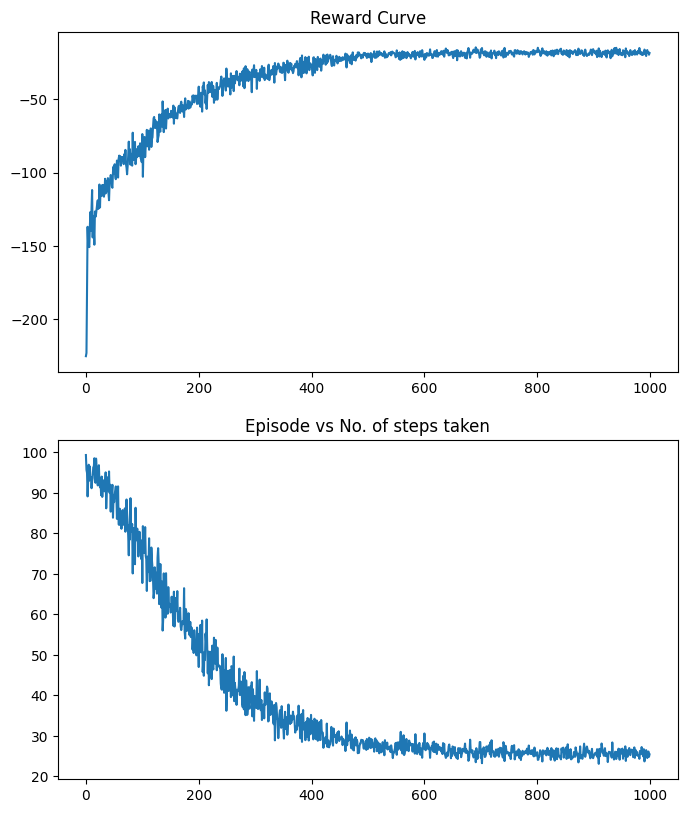

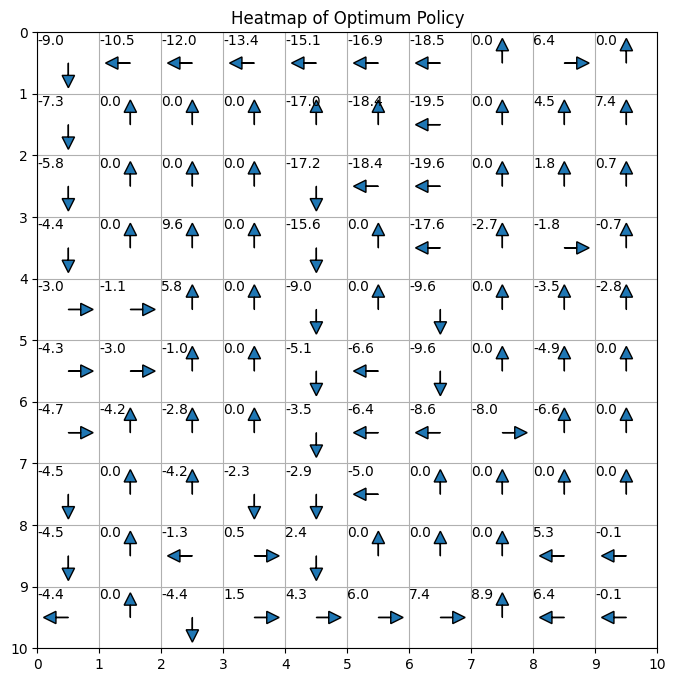

In [ ]:
#Configuration set
wind = False
p = 0.7
start = [3,6]
exploreMethod = 'e-greedy'
algo = 'q-learning'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()


##Analysis
**Description of the environment**
1. Algorithm used is Q-Learning, which means it is an Off Policy search method, with e-greedy actions taken for both exploring the state and and max of Q value taken for Q value learning.
2. Wind is False and p = 0.7, which means while the state transition can be quite stochastic.
3. We start at [3,6] which is equidistant to [0,9] and [8,7].

**Hyper-parameter analysis**
1. The best alpha is 0.1
2. The best gamma is 1.0
3. The best epsilon is 0.001

With a higher level of stochasticity (p = 0.7), the learning has clearly chosen a smaller alpha in order to slow down the learning process and make adjustments at the right place. It has chosen an undiscounted reward with gamma = 1 and a fairly greedy approach with epsilon = 0.001


**Reward Curve analysis**
1. As one can guess, with stochasticity, the learning takes longer to converge and in this case it has taken over 400 episodes to start converging. Lot of paths especially to the left of the gridworld has been explored.
2. The average reward is still not optimal with average rewards around -40.
3. Even after reasonable convergence, there is fair bit of volatility owing the p-value.

**No of steps curve analysis**
1. Just like rewards, no. of steps is also slower to converge taking more than 200 episodes to settle at an average steps of 20 eventually.

**Visit count heatmap analysis**
1. With a lower p = 0.7, the training has explored left side of the grid more often and has seem to have found the goal state [2,2] more consistently than any of the other goals. One can also above that a lot of the previously not so explored states have been explored in this configuration.

**Learnt policy analysis**
1. *Policy towards [0,9]*
The training has been considering goals [2,2] and [8,7] more than [0,9], owing to the nature of the stochasticity and the geneeral nudge towards the left side of the grid world.

2. *Policy towards [2,2]*
There is a reasonable policy towards this goal, however it is not fully deterministic as quite some number of exploration has been done on other paths too. In a nutshell, while there are many states with a clear policy towards the goal , some of them, esp, the start state is not very clear.

3. *Policy towards [8,7]*
There is a reasonable policy towards this goal, however it is not fully deterministic as quite some number of exploration has been done on other paths too.

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have bee visited too in this process


### (16) Configuration id Q-Learning - 8

#### Configuration Parameters
Learning algorithm = Q Learning

Wind = False

Start State = [3,6]

Value of $p$ = 0.7

Exploration strategy = Softmax

<IPython.core.display.Javascript object>

<ipython-input-7-38229ae5e193>:27: RuntimeWarning:

overflow encountered in exp

<ipython-input-7-38229ae5e193>:28: RuntimeWarning:

overflow encountered in exp

<ipython-input-7-38229ae5e193>:28: RuntimeWarning:

invalid value encountered in divide



Best Hyper-parameters
The best alpha is 0.1
The best gamma is 1.0
The best epsilon is 0
The best tau is 2 
 
--------------------------------------------------------


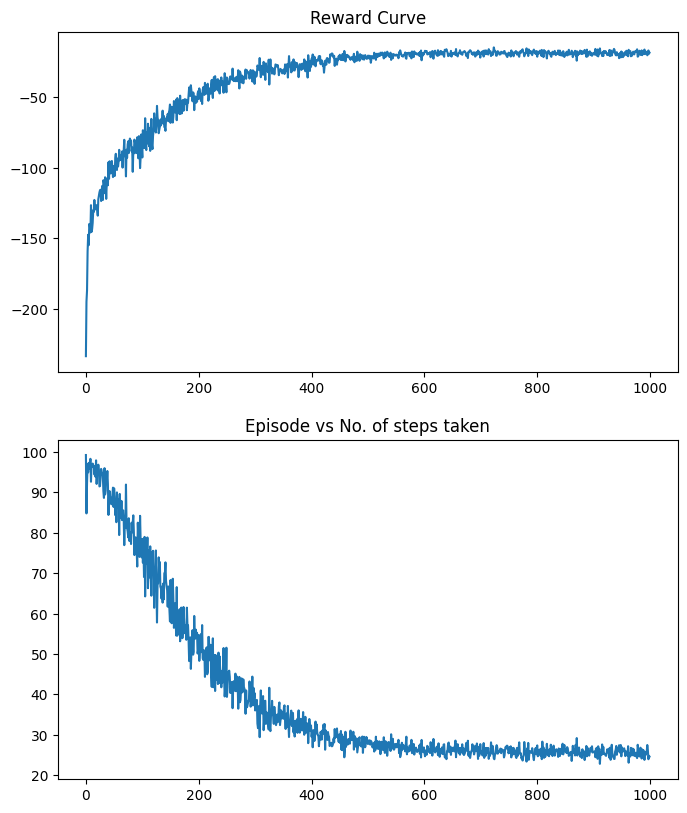

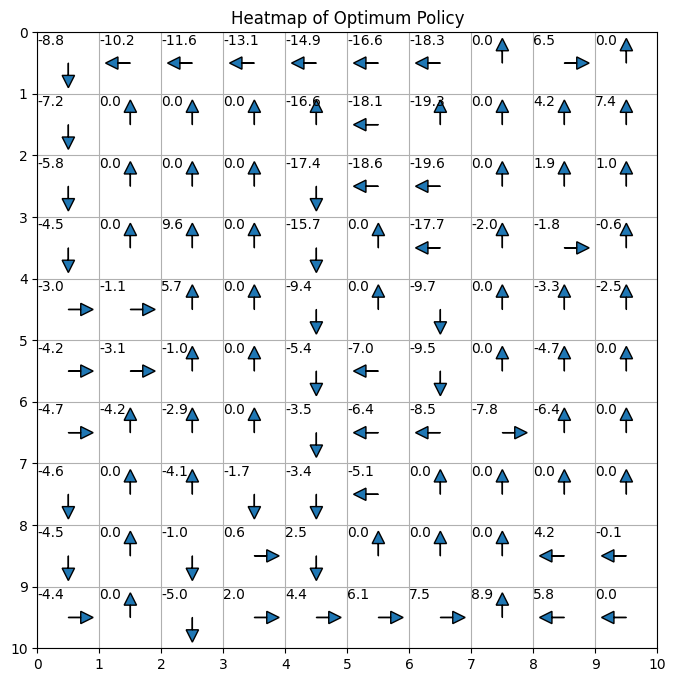

In [ ]:
#Configuration set
wind = False
p = 0.7
start = [3,6]
exploreMethod = 'softmax'
algo = 'q-learning'
num_episodes = 1000
num_agents = 50

#Training
newTrain = Training(wind, p, start,exploreMethod,algo,num_episodes,num_agents)
newTrain.evaluateParams()

#Plot the results
newTrain.plotResults()


##Analysis
**Description of the environment**
1. Algorithm used is Q-Learning, which means it is an Off Policy search method, with e-greedy actions taken for both exploring the state and and max of Q value taken for Q value learning.
2. Wind is False and p = 0.7, which means while the state transition can be quite stochastic.
3. We start at [3,6] which is equidistant to [0,9] and [8,7].

**Hyper-parameter analysis**
1. The best alpha is 0.1
2. The best gamma is 1.0
3. The best tau is 2

With a higher level of stochasticity (p = 0.7), the learning has clearly chosen a smaller alpha in order to slow down the learning process and make adjustments at the right place. It has chosen an undiscounted reward with gamma = 1 and a fairly exploratory approach with tau = 2


**Reward Curve analysis**
1. As one can guess, with stochasticity, the learning takes longer to converge and in this case it has taken over 400 episodes to start converging. Lot of paths especially to the left of the gridworld has been explored.
2. The average reward is still not optimal with average rewards around -40.
3. Even after reasonable convergence, there is fair bit of volatility owing the p-value.

**No of steps curve analysis**
1. Just like rewards, no. of steps is also slower to converge taking more than 200 episodes to settle at an average steps of 20 eventually.

**Visit count heatmap analysis**
1. With a lower p = 0.7, the training has explored left side of the grid more often and has seem to have found the goal state [2,2] more consistently than any of the other goals. One can also above that a lot of the previously not so explored states have been explored in this configuration.

**Learnt policy analysis**
1. *Policy towards [0,9]*
The training has been considering goals [2,2] and [8,7] more than [0,9], owing to the nature of the stochasticity and the geneeral nudge towards the left side of the grid world.

2. *Policy towards [2,2]*
There is a reasonable policy towards this goal, however it is not fully deterministic as quite some number of exploration has been done on other paths too. In a nutshell, while there are many states with a clear policy towards the goal , some of them, esp, the start state is not very clear.

3. *Policy towards [8,7]*
There is a reasonable policy towards this goal, however it is not fully deterministic as quite some number of exploration has been done on other paths too.

Overall this has been similar to the e-greedy for the same set of configurations

**Other observations**
1. Restart states have been clearly avoided
2. Bad states have bee visited too in this process


###Original Questions in the Colab shared by IITM
(These questions have been addressed in the sections above)

1. Plot reward curves (during the training phase with the best hyperparameters).

In [ ]:
# write your code here

2. Plot the number of steps to reach the goal in each episode (during the training phase with the best hyperparameters).

In [ ]:
# write your code here


3. Heatmap of the grid with state visit counts, i.e., the number of times each state was visited throughout the training phase.

In [ ]:
# write your code here


4. Heatmap of the grid with Q values after training is complete, and optimal actions for the best policy.

In [ ]:
# write your code here

## Analysis [36 Marks]

### SARSA [18 Marks]

[10 marks] 1. Provide a written description of the policy learnt, explaining the behavior of the agent, and your choice of hyperparameters.

Your Answer:

In [ ]:
# Optional: any supplementary code

[08 marks] 2. This description should also provide information about how the behavior changes with and without the wind, for different levels of stochasticity and for different start states.

Your Answer:

In [ ]:
# Optional: any supplementary code

Optional Comments:

### Q Learning [18 Marks]

[10 marks] 1. Provide a written description of the policy learnt, explaining the behavior of the agent, and your choice of hyperparameters.

Your Answer:

In [ ]:
# Optional: any supplementary code

[08 marks] 2. This description should also provide information about how the behavior changes with and without the wind, for different levels of stochasticity and for different start states.

Your Answer:

In [ ]:
# Optional: any supplementary code

Optional Comments: